# Elliptic PDE in 1 dimension

Authored by Aleksei G. Sorokin

## Setup

In [1]:
import os
import sys; 
sys.path.append("../")

In [2]:
import fastgps
import qmcpy as qp
import chonknoris
import gpytorch
import torch
import numpy as np

In [3]:
torch.set_default_dtype(torch.float64)
assert torch.cuda.is_available()
DEVICE = "cuda"

In [4]:
ROOT = "."
assert os.path.isfile(ROOT+"/elliptic_1d.ipynb")

In [5]:
from matplotlib import pyplot,colors,cm,cycler
import pandas as pd
pyplot.style.use('seaborn-v0_8-whitegrid')
COLORS = ["xkcd:"+color[:-1] for color in pd.read_csv(ROOT+"/../../chonknoris/xkcd_colors.txt",comment="#",header=None).iloc[:,0].tolist()][::-1]
pyplot.rcParams['axes.prop_cycle'] = cycler(color=COLORS)

## Parameters

In [6]:
FACTOR = 50
num_realizations = 2**10  # Number of realizations
N = 63  # Number of grid points
L_domain = 1.0  # Length of the domain [0, 1]
x = torch.linspace(0,L_domain,N+2,device=DEVICE)[1:-1] # L*(0/N, 1/N, ..., (N-1)/N)
dx = x[1]-x[0]
x

tensor([0.0156, 0.0312, 0.0469, 0.0625, 0.0781, 0.0938, 0.1094, 0.1250, 0.1406,
        0.1562, 0.1719, 0.1875, 0.2031, 0.2188, 0.2344, 0.2500, 0.2656, 0.2812,
        0.2969, 0.3125, 0.3281, 0.3438, 0.3594, 0.3750, 0.3906, 0.4062, 0.4219,
        0.4375, 0.4531, 0.4688, 0.4844, 0.5000, 0.5156, 0.5312, 0.5469, 0.5625,
        0.5781, 0.5938, 0.6094, 0.6250, 0.6406, 0.6562, 0.6719, 0.6875, 0.7031,
        0.7188, 0.7344, 0.7500, 0.7656, 0.7812, 0.7969, 0.8125, 0.8281, 0.8438,
        0.8594, 0.8750, 0.8906, 0.9062, 0.9219, 0.9375, 0.9531, 0.9688, 0.9844],
       device='cuda:0')

## Reference data

### RHS $u$

/home/agsorok/miniconda3/envs/chonknoris/lib/python3.12/site-packages/linear_operator/utils/cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(


u.shape = (1024, 63)


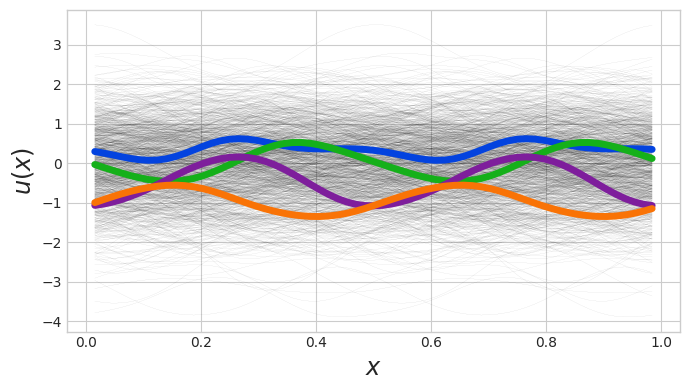

In [7]:
u_kernel = gpytorch.kernels.PeriodicKernel()
u_kernel.period_length = 1/2
u_kernel.lengthscale = 10.
u_gp = chonknoris.GP(
    x = torch.zeros((0,1)).to(DEVICE),
    y = torch.zeros(0).to(DEVICE),
    mean_module = gpytorch.means.ZeroMean(),
    covar_module = u_kernel)
u_gp = u_gp.to(DEVICE)
u_x_mvn = u_gp.forward(x)
u = u_x_mvn.sample(torch.Size([num_realizations]),base_samples=torch.randn(num_realizations,N,generator=torch.Generator().manual_seed(11)).to(DEVICE))
print("u.shape = %s"%str(tuple(u.shape)))
fig,ax = pyplot.subplots(nrows=1,ncols=1,figsize=(7,4))
ax.plot(x.to("cpu"),u.T.to("cpu"),color="k",linewidth=.025)
for i,ii in enumerate([3,7,11,13]):
    ax.plot(x.to("cpu"),u[ii].to("cpu"),linewidth=5)#,color=COLORS[i])
ax.set_xlabel(r"$x$",fontsize="xx-large")
ax.set_ylabel(r"$u(x)$",fontsize="xx-large");
fig.tight_layout()
# fig.savefig("out/u_samples.pdf")

### Initial guess $v_0$

v0.shape = (1024, 63)


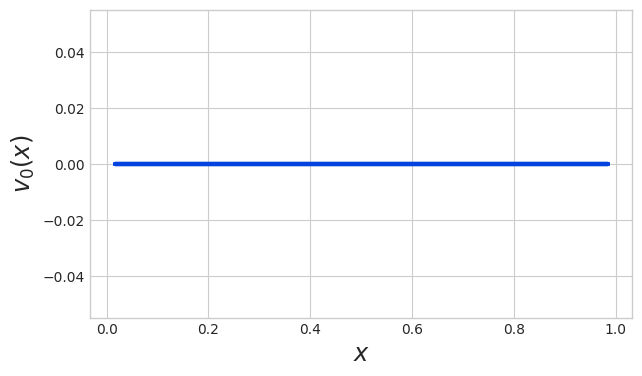

In [8]:
v0 = torch.zeros((num_realizations,N),device=DEVICE)
print("v0.shape = %s"%str(tuple(u.shape)))
fig,ax = pyplot.subplots(nrows=1,ncols=1,figsize=(7,4))
ax.plot(x.to("cpu"),v0.T.to("cpu"),color="k",linewidth=.5)
ax.plot(x.to("cpu"),v0[:4].T.to("cpu"),linewidth=3,color=COLORS[0])
ax.set_xlabel(r"$x$",fontsize="xx-large")
ax.set_ylabel(r"$v_0(x)$",fontsize="xx-large");

### Gauss-Newton solver

In [9]:
def pde_solve(
        u, 
        v0, 
        num_newton_iter = 6, 
        relaxation = 0, 
        lr = 1, 
        line_search = False, 
        line_search_c1 = 1e-4, 
        line_search_beta = .3,
        line_search_min_lr = 1e-16,
        laplace_wraparound = False,
        vref = None, 
        predict_Linvs = None, 
        predict_diff = None,
        store_Linvs = False, 
        verbose = True,
        verbose_indent = 4):
    times = torch.empty(num_newton_iter+1)
    t0 = torch.cuda.Event(enable_timing=True)
    tend = torch.cuda.Event(enable_timing=True)
    t0.record()
    assert u.ndim==v0.ndim==2 and u.shape==v0.shape
    assert vref is None or vref=="last" or isinstance(vref,torch.Tensor)
    R = len(u) # number of realizations
    Nrange = torch.arange(N)
    # A_laplace.shape == (N,N)
    A_laplace = torch.zeros((N,N),device=DEVICE)
    A_laplace[Nrange,Nrange] = -2 
    A_laplace[Nrange[1:],Nrange[:-1]] = 1
    A_laplace[Nrange[:-1],Nrange[1:]] = 1
    if laplace_wraparound:
        assert relaxation>0, "laplace_wraparound=True requires relaxation>0"
        assert line_search, "laplace_wraparound=True seems to only work when using line search"
        A_laplace[0,-1] = 1 
        A_laplace[-1,0] = 1
    A_laplace = A_laplace/dx**2
    vs = torch.empty((R,num_newton_iter+1,N))
    resid = torch.empty((R,num_newton_iter+1,N))
    rmse_resid = torch.empty(R,num_newton_iter+1)
    if store_Linvs:
        Linvs = torch.zeros((R,num_newton_iter,N,N))
    if line_search:
        lr_lss = torch.empty((R,num_newton_iter))
    if isinstance(vref,torch.Tensor):
        assert vref.shape==(R,N)
        vrefnorm = torch.linalg.norm(vref,dim=1)
        l2rerrors = torch.empty((R,num_newton_iter+1))
    if verbose:
        _vstr = " "*verbose_indent+"%-15s| %-10s| %-52s|"%("iter of %-6d"%num_newton_iter,"time","RMSE residual")
        if isinstance(vref,torch.Tensor):
            _vstr += " %-52s|"%"L2 relative error"
        print(_vstr)
        _vstr = " "*verbose_indent+"%-15s| %-10s| %-13s%-13s%-13s%-13s|"%(" "*15," "*10,"5%","median","mean","95%")
        if isinstance(vref,torch.Tensor):
            _vstr += " %-13s%-13s%-13s%-13s|"%("5%","median","mean","95%")
        print(_vstr)
        _vstr = " "*verbose_indent+"-"*82 
        if isinstance(vref,torch.Tensor):
            _vstr += "-"*54
        print(_vstr)
    # v.shape==u.shape==residual.shape==(R,N)
    v = v0
    residual = u-(-torch.einsum("ik,rk->ri",A_laplace,v)+FACTOR*v**3) # u-P(v)
    for i in range(num_newton_iter+1):
        vs[:,i,:] = v.cpu()
        resid[:,i,:] = residual.cpu()
        rmse_resid[:,i] = torch.sqrt(torch.mean(residual**2,1)).cpu()
        if isinstance(vref,torch.Tensor):
            l2rerrors[:,i] = torch.linalg.norm(v-vref,dim=1)/vrefnorm
        tend.record()
        torch.cuda.synchronize()
        times[i] = t0.elapsed_time(tend)/1000/R
        t0 = torch.cuda.Event(enable_timing=True)
        tend = torch.cuda.Event(enable_timing=True)
        t0.record()
        if verbose and (i%verbose==0 or i==num_newton_iter):
            _vstr = " "*verbose_indent+"%-15d| %-10.2e| %-13.2e%-13.2e%-13.2e%-13.2e|"%(i,times[i]*R,
                    torch.quantile(rmse_resid[:,i],.05),torch.quantile(rmse_resid[:,i],.5),torch.mean(rmse_resid[:,i]),torch.quantile(rmse_resid[:,i],.95))
            if isinstance(vref,torch.Tensor):
                _vstr += " %-13.2e%-13.2e%-13.2e%-13.2e|"%(
                    torch.quantile(l2rerrors[:,i],.05),torch.quantile(l2rerrors[:,i],.5),torch.mean(l2rerrors[:,i]),torch.quantile(l2rerrors[:,i],.95))
            print(_vstr)
        if i==num_newton_iter: break
        # dPdv.shape == (R,N,N)
        tau_prime_v = 3*FACTOR*v**2
        dPdv = torch.tile(-A_laplace,(R,1,1))
        dPdv[:,Nrange,Nrange] = dPdv[:,Nrange,Nrange]+tau_prime_v # add to diagonals
        b = torch.einsum("rik,ri->rk",dPdv,residual)
        if predict_diff is None:
            if predict_Linvs is None: 
                # Theta.shape==(R,N,N)
                Theta = torch.einsum("rki,rkj->rij",dPdv,dPdv) # batch dPdv[r].T@dPdv[r]
                Theta[:,Nrange,Nrange] = Theta[:,Nrange,Nrange]+relaxation # add to diagonals
                # L.shape==Linv.shape==(R,N,N)
                L = torch.linalg.cholesky(Theta,upper=False)
                Linv = torch.linalg.solve_triangular(L,torch.eye(N,device=DEVICE),upper=False)
            else:
                Linv = predict_Linvs(v)
            if store_Linvs:
                Linvs[:,i,:,:] = Linv.cpu()
            # b.shape==delta.shape==v_new.shape==residual.shape==(R,N)
            delta = torch.einsum("rik,ri->rk",Linv,torch.einsum("rik,rk->ri",Linv,b)) # batch Linv[r].T@(Linv[r]@b[r])
        else:
            delta = predict_diff(torch.hstack([u,v]))
        v_new = v+lr*delta
        residual_new = u-(-torch.einsum("ik,rk->ri",A_laplace,v_new)+FACTOR*v_new**3) # u-P(v_new)
        if line_search:
            mask = torch.ones(R,dtype=bool,device=DEVICE)
            lr_ls = lr*torch.ones(R,device=DEVICE)
            _temp1 = torch.linalg.norm(residual,dim=1)**2
            _temp2 = 2*line_search_c1*(b*delta).sum(1)
            while True:
                _mask = mask.clone()
                mask[_mask] = (torch.linalg.norm(residual_new[_mask],dim=1)**2)>(_temp1[_mask]+lr_ls[_mask]*_temp2[_mask])
                if mask.sum()==0 or lr_ls[mask].min()<=line_search_min_lr: break
                lr_ls[mask] = lr_ls[mask]*line_search_beta
                v_new[mask] = v[mask]+lr_ls[mask,None]*delta[mask]
                residual_new[mask] = u[mask]-(-torch.einsum("ik,rk->ri",A_laplace,v_new[mask])+FACTOR*v_new[mask]**3) # u-P(v_new)
            lr_lss[:,i] = lr_ls.cpu()
        v = v_new 
        residual = residual_new
    data = {"vs":vs,"resid":resid,"rmse_resid":rmse_resid,"times":torch.cumsum(times,0)}
    if store_Linvs:
        data["Linvs"] = Linvs
    if line_search:
        data["lr_lss"] = lr_lss
    if vref=="last":
        vref = vs[:,-1]
        l2rerrors = torch.linalg.norm(vs-vref[:,None,:],dim=2)/torch.linalg.norm(vref[:,None,:],dim=2)
    if vref is not None:
        data["l2rerrors"] = l2rerrors
    return vs,data

### Generate data

In [10]:
vs,data = pde_solve(u,v0,num_newton_iter=5,relaxation=0.,line_search=False,laplace_wraparound=False,store_Linvs=True,vref="last")
data["u"] = u
Linvs = data["Linvs"]
for key,val in data.items():
    print('data["%s"].shape = %s'%(key,str(tuple(val.shape))))
# torch.save(data,ROOT+"/datasets/data_N%d.pth"%N)

    iter of 5      | time      | RMSE residual                                       |
                   |           | 5%           median       mean         95%          |
    ----------------------------------------------------------------------------------
    0              | 4.56e-02  | 2.24e-01     6.73e-01     8.19e-01     1.79e+00     |
    1              | 4.68e-02  | 9.79e-06     1.23e-02     7.32e-02     3.13e-01     |
    2              | 2.85e-02  | 4.13e-13     1.62e-05     3.65e-03     1.36e-02     |
    3              | 3.74e-02  | 2.08e-15     2.71e-11     4.23e-05     2.73e-05     |
    4              | 1.29e-02  | 2.03e-15     2.76e-14     2.74e-08     1.10e-10     |
    5              | 5.89e-03  | 2.03e-15     2.71e-14     5.59e-14     7.09e-14     |
data["vs"].shape = (1024, 6, 63)
data["resid"].shape = (1024, 6, 63)
data["rmse_resid"].shape = (1024, 6)
data["times"].shape = (6,)
data["Linvs"].shape = (1024, 5, 63, 63)
data["l2rerrors"].shape = (1024, 6)
data["u"

### Train Test Split

In [ ]:
(u_t,u_v,vs_t,vs_v,Linvs_t,Linvs_v),vidx = chonknoris.train_val_split(u,vs,Linvs,val_frac=1/8,shuffle=True,rng_shuffle_seed=7)
print("u_t.shape = %s"%str(tuple(u_t.shape)))
print("vs_t.shape = %s"%str(tuple(vs_t.shape)))
print("Linvs_t.shape = %s"%str(tuple(Linvs_t.shape)))
print()
print("u_v.shape = %s"%str(tuple(u_v.shape)))
print("vs_v.shape = %s"%str(tuple(vs_v.shape)))
print("Linvs_v.shape = %s"%str(tuple(Linvs_v.shape)))
# torch.save(
#     {
#         "u_t": u_t.cpu(),
#         "v_t": vs_t[:,-1,:].cpu(),
#         "u_v": u_v.cpu(),
#         "v_v": vs_v[:,-1,:].cpu(),
#     },
#     ROOT+"/out/elliptic_pde_1d.data_N%d.train_val.pt"%N)

u_t.shape = (896, 63)
vs_t.shape = (896, 6, 63)
Linvs_t.shape = (896, 5, 63, 63)

u_v.shape = (128, 63)
vs_v.shape = (128, 6, 63)
Linvs_v.shape = (128, 5, 63, 63)


### Plots

/data2/agsorok/CHONKNORIS/chonknoris/plots.py:159: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[i,j].legend(frameon=False,fontsize="xx-large")


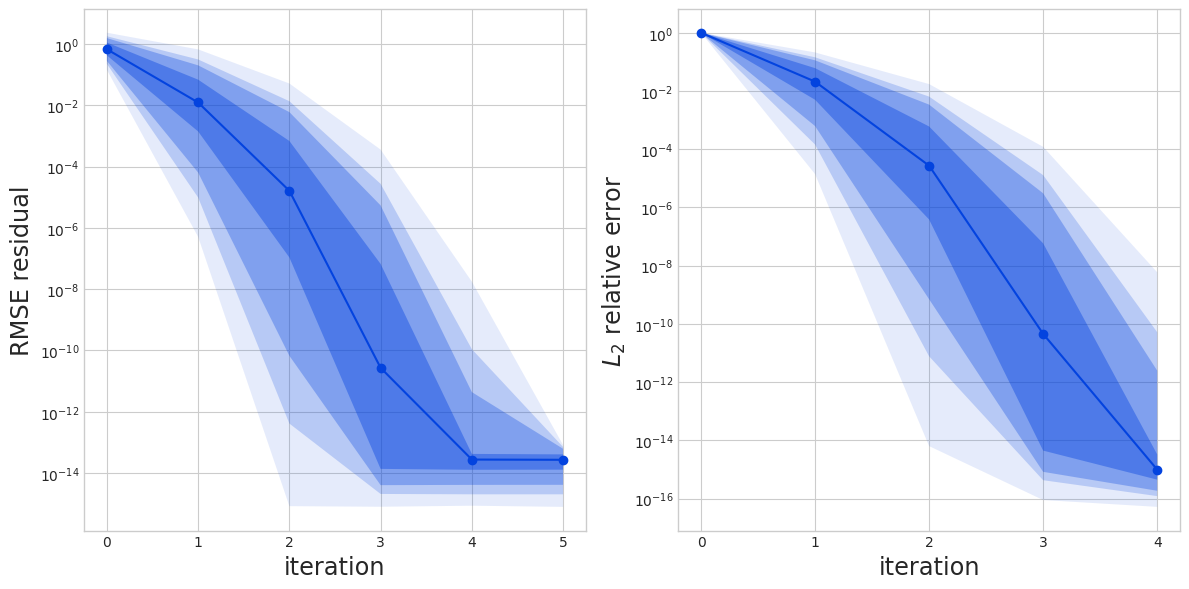

In [12]:
fig,ax = chonknoris.plot_band_strand(
    data = [
        [
            [(None,data["rmse_resid"],None)],
            [(None,data["l2rerrors"][:,:-1],None)],

        ]
    ],
    sharex = False,
    ylabels = [["RMSE residual",r"$L_2$ relative error"]],
    xlabels = "iteration",
    xlogscale = False,
    # colors = [COLORS[0]],
    ylogscale = True)
ax[0,1].set_xticks([i for i in range(data["l2rerrors"][:,:-1].size(1))]);
fig.tight_layout()
# fig.savefig("figs/reference_convergence.pdf")

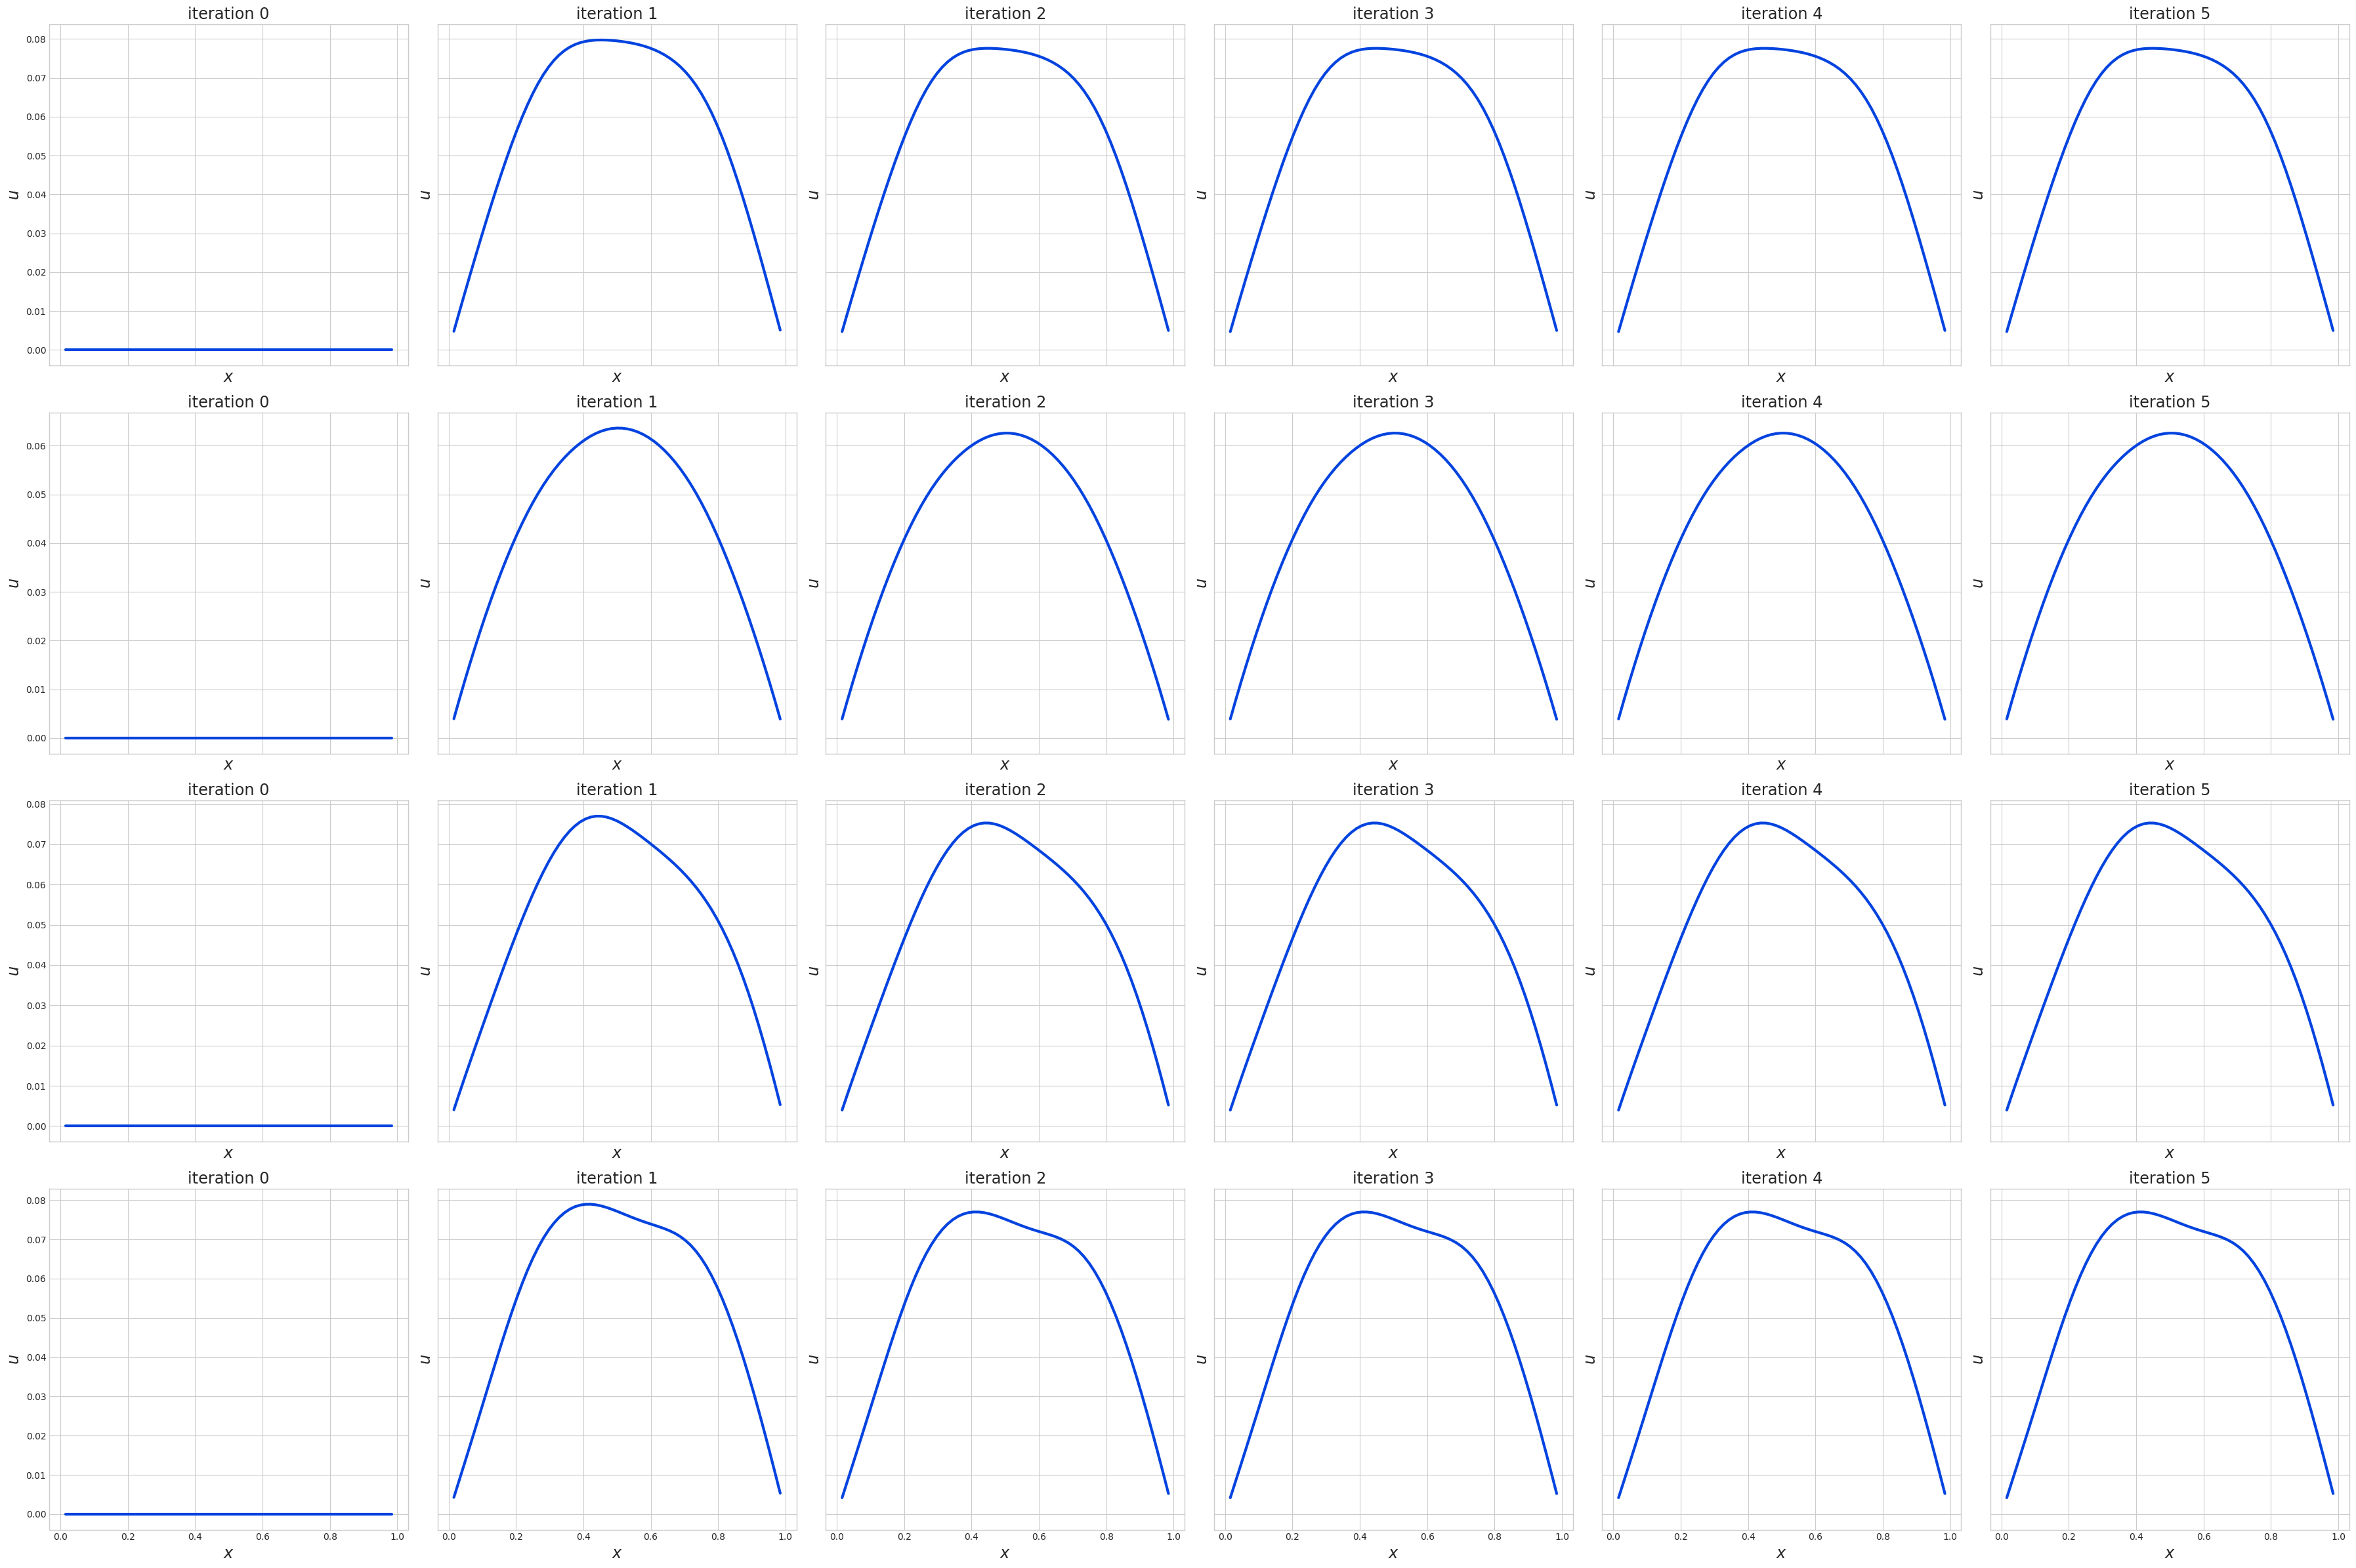

In [13]:
fig,ax = chonknoris.plot_band_strand(
    data = [[[(x.cpu(),vs_v[i,j].cpu(),None)] for j in range(vs_v.size(1))] for i in range(4)],
    marker = None, 
    plot_strands = True, 
    plot_median = False, 
    qlows=[], 
    qhighs = [], 
    plt_band_alphas=[],
    LWTHIN=3,
    sharex = True,
    sharey = "row", 
    xlabels = r"$x$",
    ylabels = r"$u$",
    colors=[COLORS[0]],
    titles = ["iteration %d"%j for j in range(vs_v.size(1))],
)

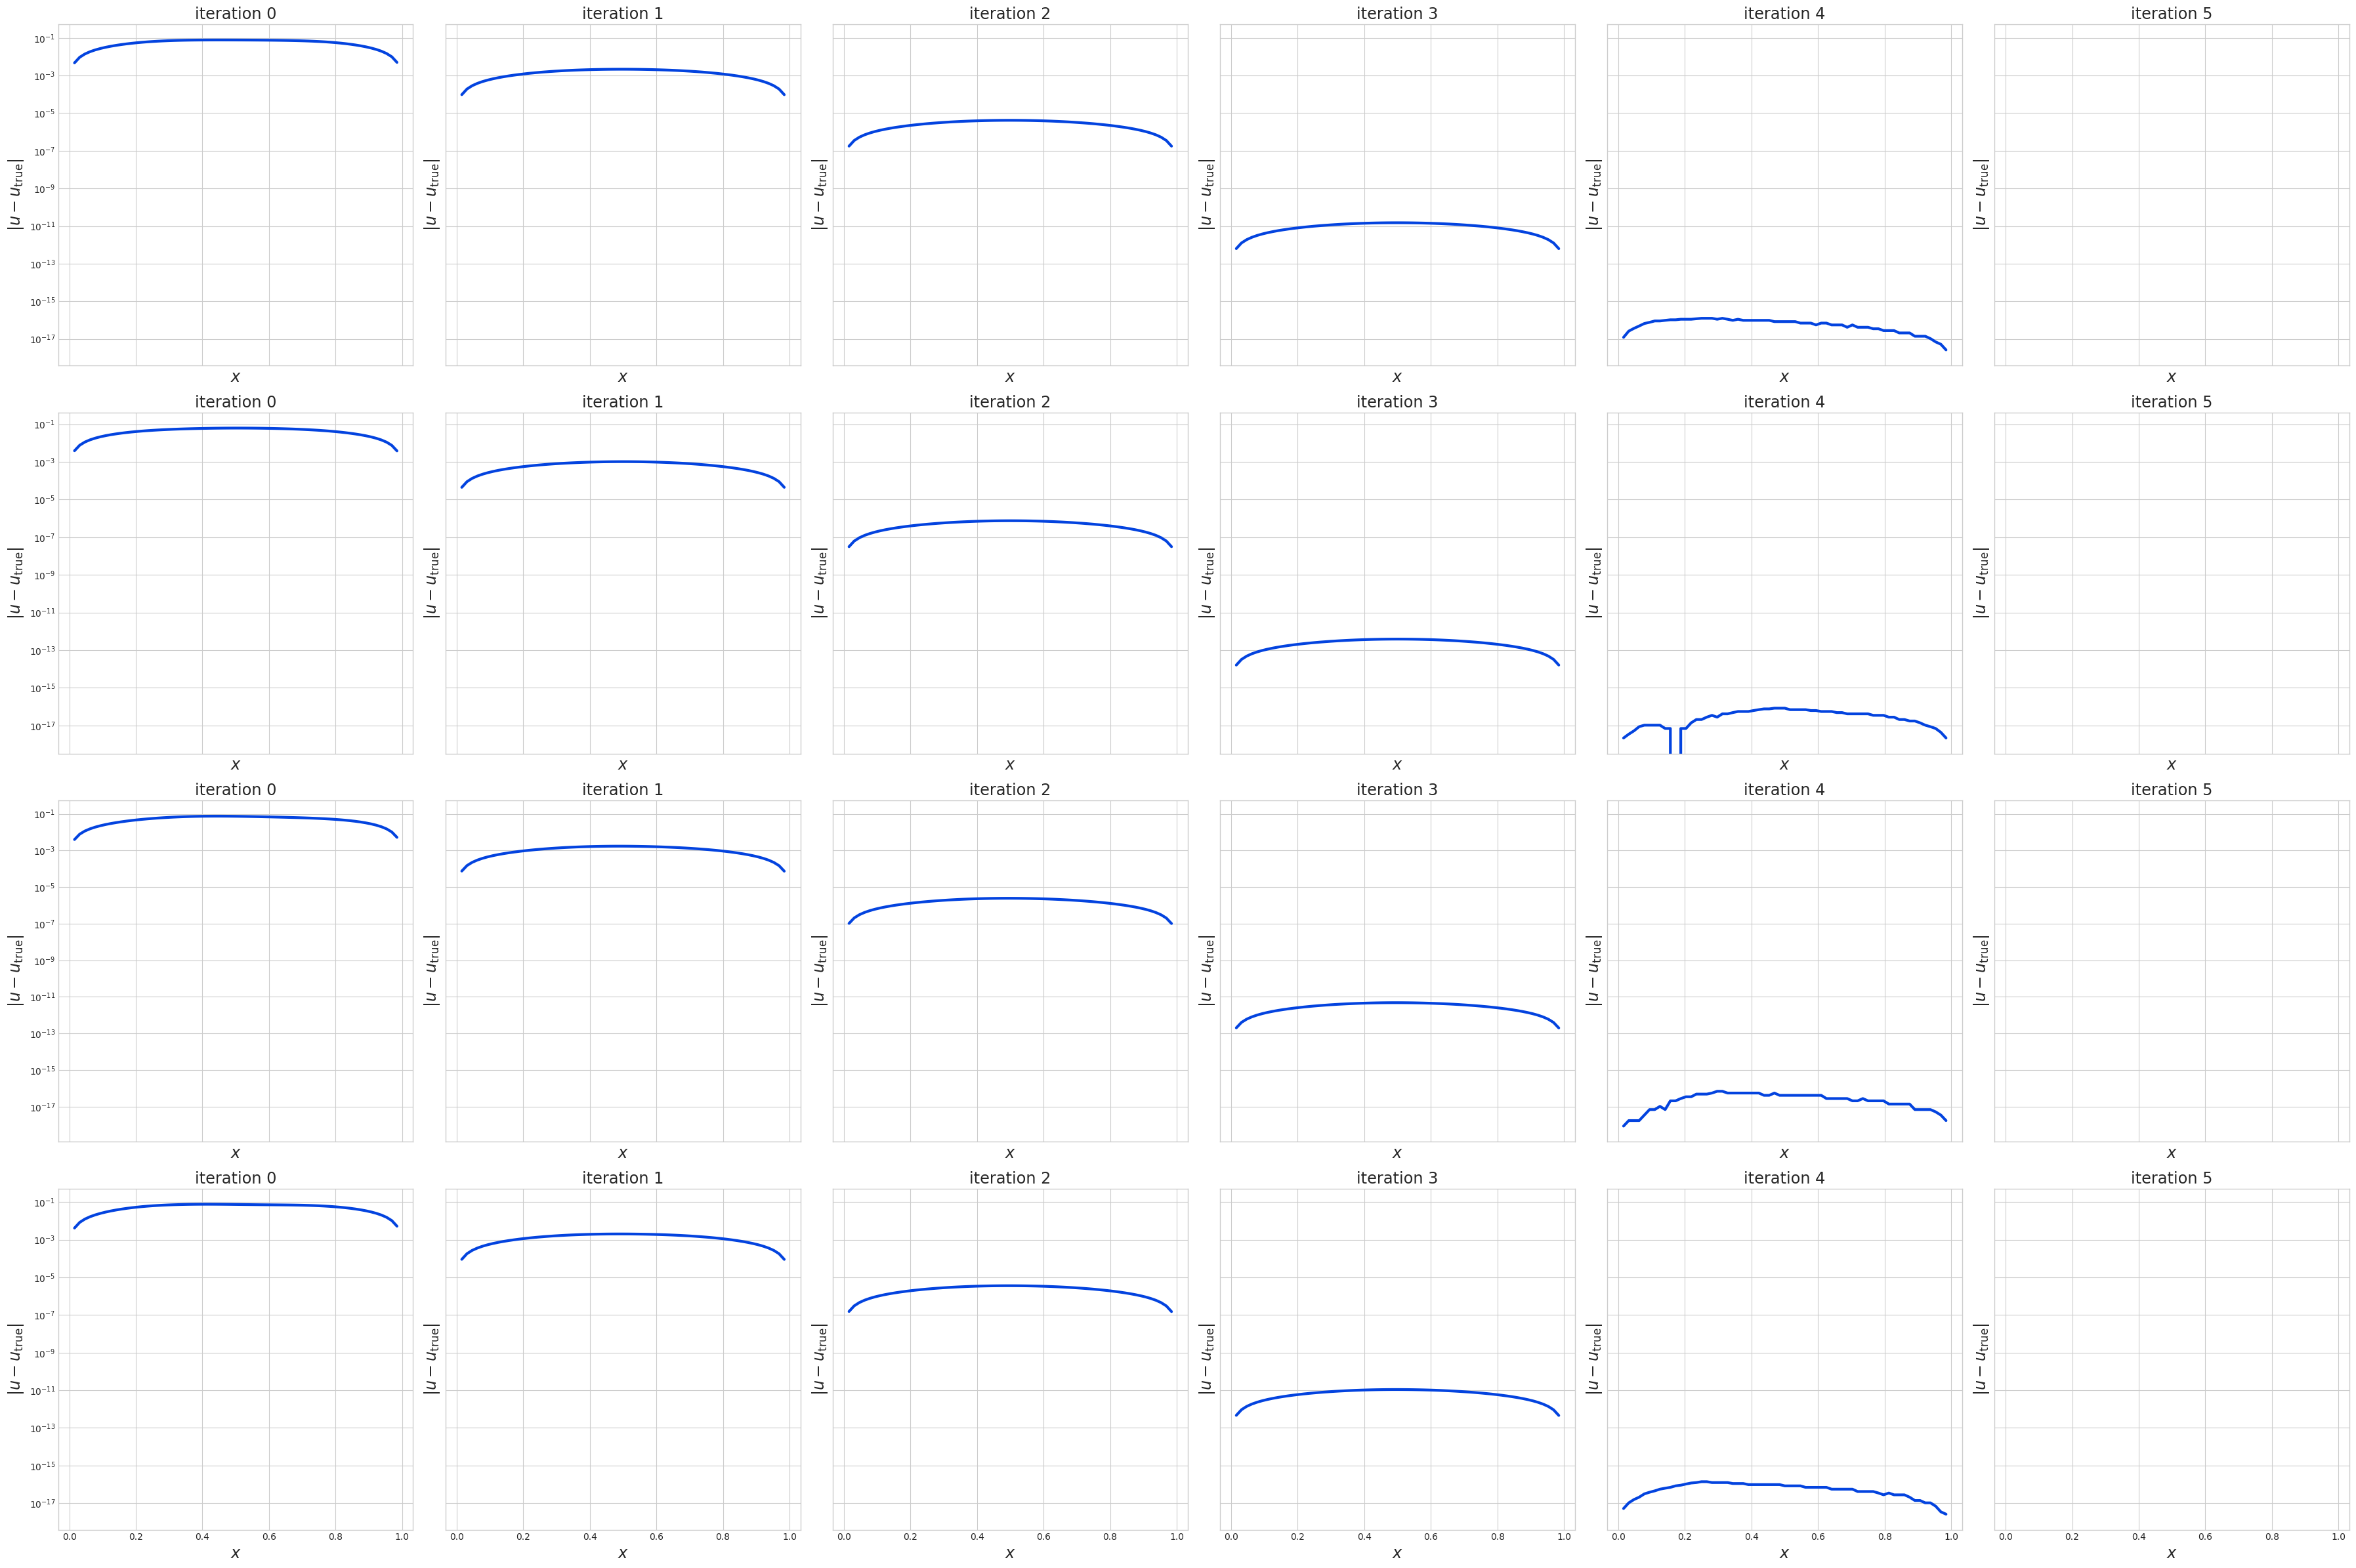

In [14]:
fig,ax = chonknoris.plot_band_strand(
    data = [[[(x.cpu(),torch.abs(vs_v[i,j]-vs_v[i,-1]).cpu(),None)] for j in range(vs_v.size(1))] for i in range(4)],
    marker = None, 
    plot_strands = True, 
    plot_median = False, 
    qlows=[], 
    qhighs = [], 
    plt_band_alphas=[],
    LWTHIN=3,
    sharex = True,
    sharey = "row", 
    ylogscale=True,
    colors=[COLORS[0]],
    xlabels = r"$x$",
    ylabels = r"$|u-u_\text{true}|$",
    titles = ["iteration %d"%j for j in range(vs_v.size(1))],
)

## Operator Learning Initial Guess

     iter of 2.5e+02 | best loss  | loss      
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
            0.00e+00 | 2.45e+04   | 2.45e+04  
            2.50e+01 | -4.25e+05  | -4.25e+05 
            5.00e+01 | -4.28e+05  | -4.28e+05 
            7.50e+01 | -4.29e+05  | -4.29e+05 
            1.00e+02 | -4.29e+05  | -4.29e+05 
            1.25e+02 | -4.29e+05  | -4.29e+05 
            1.50e+02 | -4.30e+05  | -4.30e+05 
            1.75e+02 | -4.30e+05  | -4.30e+05 
            2.00e+02 | -4.30e+05  | -4.30e+05 
            2.25e+02 | -4.30e+05  | -4.30e+05 
            2.50e+02 | -4.30e+05  | -4.30e+05 


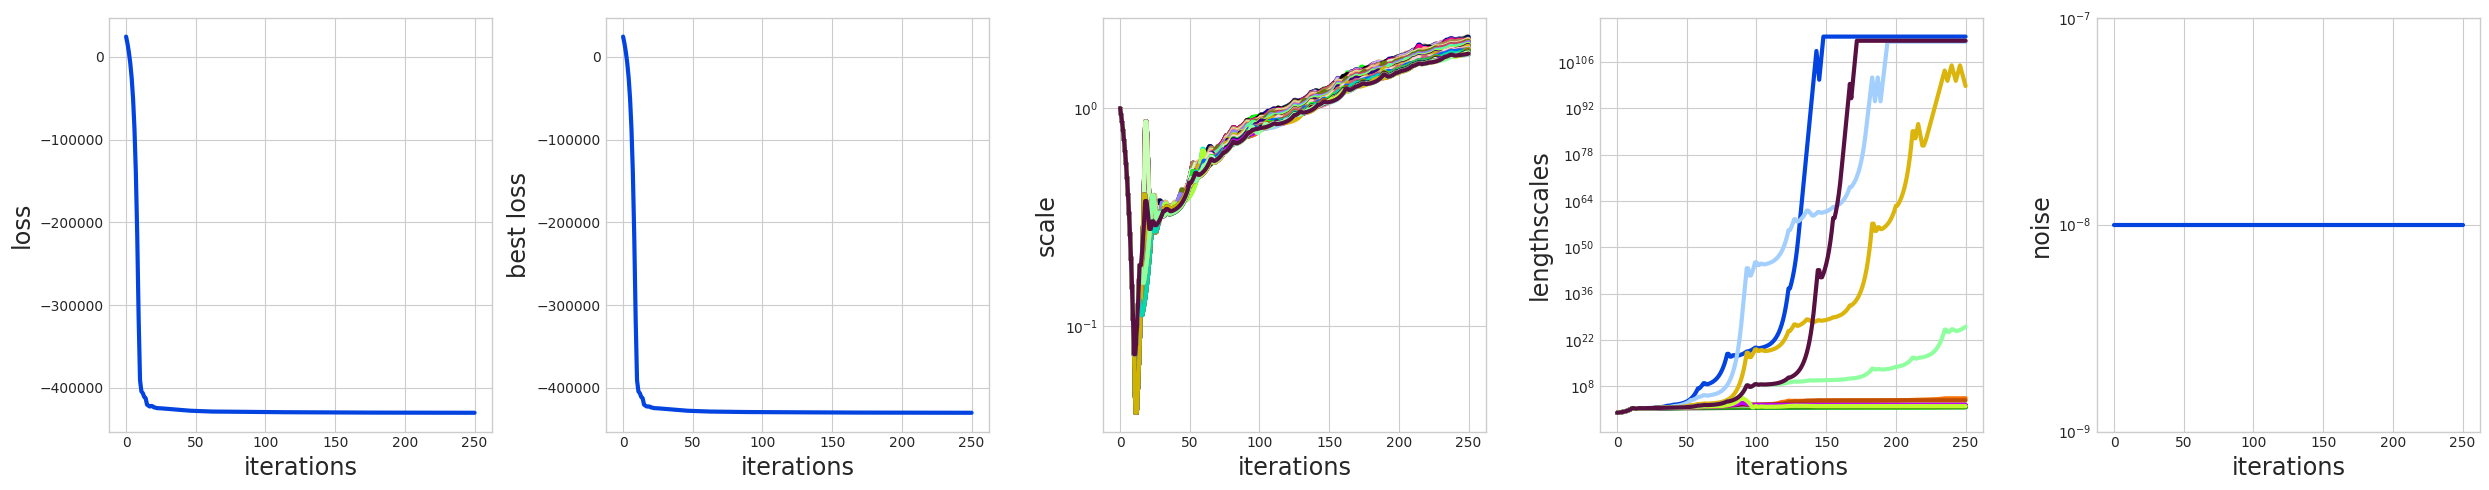

In [15]:
load_params = False 
save_params = False
iterations = 250
d_in = N
d_out = N
ig_x = u_t.to(DEVICE)
ig_x_mean = ig_x.mean(0) 
ig_x_std = ig_x.std(0) 
ig_x_normed = (ig_x-ig_x_mean)/ig_x_std
# _,_,pcamat_ig_x = torch.pca_lowrank(ig_x_normed,q=ig_x_normed.size(-1))
# ig_x_pca = ig_x_normed@pcamat_ig_x
# ig_x_pca_mean = ig_x_pca.mean(0)
# ig_x_pca_std = ig_x_pca.std(0)
# ig_x_pca_normed = (ig_x_pca-ig_x_pca_mean)/ig_x_pca_std
ig_y = vs_t[:,-1,:].to(DEVICE)
ig_y_mean = ig_y.mean(0)
ig_y_std = ig_y.std(0)
ig_y_normed = (ig_y-ig_y_mean)/ig_y_std
# _,_,pcamat_ig_y = torch.pca_lowrank(ig_y_normed,q=ig_y_normed.size(-1))
# pcamat_ig_y = torch.eye(pcamat_ig_y.size(-1),device=pcamat_ig_y.device)
# ig_y_pca = ig_y_normed@pcamat_ig_y
# ig_y_pca_mean = ig_y_pca.mean(0)
# ig_y_pca_std = ig_y_pca.std(0)
# ig_y_pca_normed = (ig_y_pca-ig_y_pca_mean)/ig_y_pca_std
fgp_ig = fastgps.StandardGP(
    qp.KernelRationalQuadratic(
        d_in,
        scale = 1, 
        shape_scale = [d_in,1],
        lengthscales = 1, 
        shape_lengthscales = [d_in],
        torchify = True,
        compile_call = True,
        device=DEVICE),
    {"x":ig_x_normed,"y":ig_y_normed.T},
    noise = 1e-8, 
    shape_noise = [1],
    requires_grad_noise = False, 
)
if load_params: 
    fgp_ig.load_params("./out/fgp_ig_params.pt")
fit_data_fgp_ig = fgp_ig.fit(
    loss_metric = "MLL",
    # loss_metric = "CV",
    cv_weights = 1/torch.linalg.norm(ig_y_normed,dim=-1),
    iterations = iterations, 
    stop_crit_wait_iterations = np.inf,
    store_hists = True,
    verbose = 25,
    # lr = 2.5e-2,
)
fastgps.plot_fastgps_fit_data(fit_data_fgp_ig,["loss","best_loss","scale","lengthscales","noise"]);
if save_params:
    fgp_ig.save_params("./out/fgp_ig_params.pt")

In [16]:
with torch.no_grad(), torch.inference_mode(), gpytorch.settings.fast_pred_var(), chonknoris.TorchNumThreadsContext(1):
    t0 = torch.cuda.Event(enable_timing=True)
    tend = torch.cuda.Event(enable_timing=True)
    t0.record()
    if True:
        _ig_tf_x = (u_v.to(DEVICE)-ig_x_mean)/ig_x_std
        # _ig_tf_x = ((((u_v.to(DEVICE)-ig_x_mean)/ig_x_std)@pcamat_ig_x)-ig_x_pca_mean)/ig_x_pca_std
        _ig_tf_y = fgp_ig.post_mean(_ig_tf_x).T
        v0hat_v_fastgp = ig_y_mean+ig_y_std*_ig_tf_y
        # v0hat_v_fastgp = ig_y_mean+ig_y_std*((ig_y_pca_mean+ig_y_pca_std*_ig_tf_y)@(pcamat_ig_y.conj().T))
    else:
        v0hat_v_fastgp = torch.from_numpy(np.load("./elliptic_pde_predictions.npz")["pred"]).to(DEVICE)
    tend.record()
    torch.cuda.synchronize()
    time_ig_fastgp = t0.elapsed_time(tend)/1000
print("%s inferance time: %.2e"%("time_ig_fastgp",time_ig_fastgp))
# print("median L2 relative error: %.2e"%torch.median(torch.linalg.norm(v0hat_v_fastgp-ig_y,dim=-1)/torch.linalg.norm(ig_y,dim=-1)))
print("median L2 relative error: %.2e"%torch.median(torch.linalg.norm(v0hat_v_fastgp.cpu()-vs_v[:,-1,:],dim=-1)/torch.linalg.norm(vs_v[:,-1,:],dim=-1)))

time_ig_fastgp inferance time: 3.93e-01
median L2 relative error: 2.40e-05


### Inference

In [17]:
dict_v0s_times = {
    "reference":(v0[vidx],0.),
    "GP":(v0hat_v_fastgp,time_ig_fastgp),
}
data_igs = {}
print("models %s: "%str(list(dict_v0s_times.keys())),end='',flush=True)
for tag,(v0hat_v,tv0) in dict_v0s_times.items():
    print("%s, "%tag,end='',flush=True)
    with chonknoris.TorchNumThreadsContext(1):
        _,data_igs[tag] = pde_solve(u_v,v0hat_v,num_newton_iter=5,relaxation=0,vref=vs_v[:,-1,:].to(DEVICE),verbose=False)
    data_igs[tag]["times"] += tv0
print()

models ['reference', 'GP']: reference, GP, 


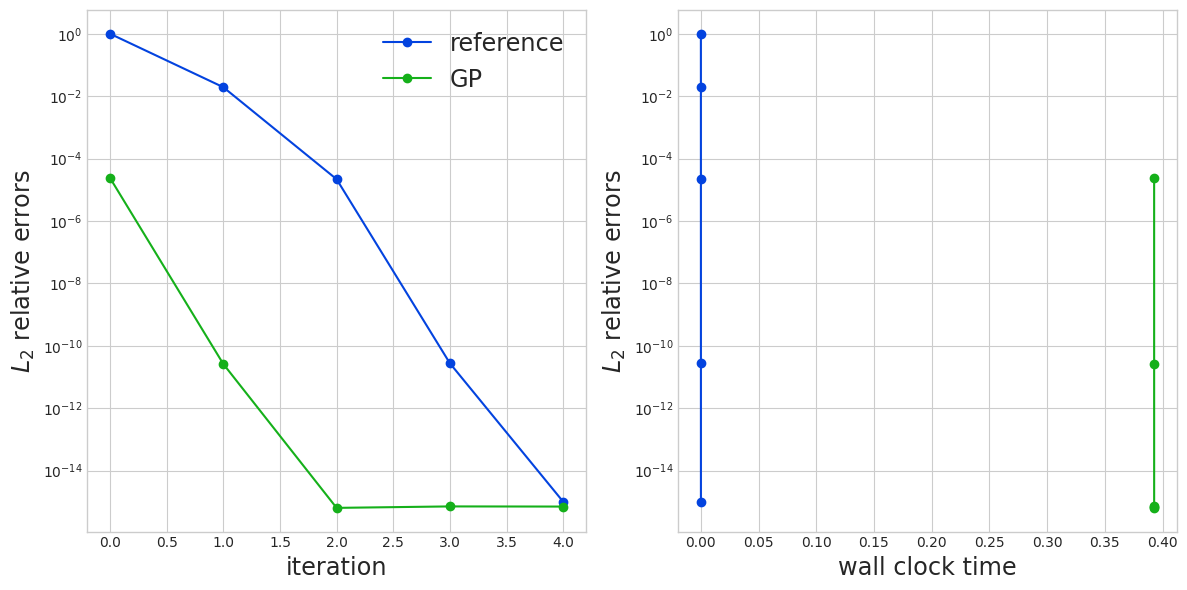

In [18]:
hidden_models = ["GP Indep Vec Exact Shared","GP Indep Vec Exact Batch"]
fig,ax = chonknoris.plot_band_strand(
    [
        [
            [(None,data_ig["l2rerrors"][:,:-1],name.replace("GP Indep Vec Approx","GP IP").replace("GP Vec Approx Latent","GP IP Latent").replace("GP Indep Vec Approx","GP")) for name,data_ig in data_igs.items() if name not in hidden_models],
            [(data_ig["times"][:-1],data_ig["l2rerrors"][:,:-1],name.replace("GP Indep Vec Approx","GP IP").replace("GP Vec Approx Latent","GP IP Latent").replace("GP Indep Vec Approx","GP")) for name,data_ig in data_igs.items() if name not in hidden_models],
        ]
    ],
    ylabels = [2*[r"$L_2$ relative errors"]],
    xlabels = [["iteration","wall clock time"]],
    xlogscale = False,
    ylogscale = True,
    qhighs=[],
    qlows=[],
    plt_band_alphas=[],
    sharex=None,
    sharey=False,
)
for i in range(2):
    ax[0,i].get_legend().remove()
ax[0,0].legend(frameon=False,fontsize="xx-large",ncols=1)#,loc="lower center",ncol=3,bbox_to_anchor=(1.1,-.3));
#ax[0,1].legend(frameon=False,fontsize="xx-large")#,loc="lower center",ncol=3,bbox_to_anchor=(1.1,-.3));
#fig.tight_layout()
fig.savefig("out/initial_guess_inference.pdf")

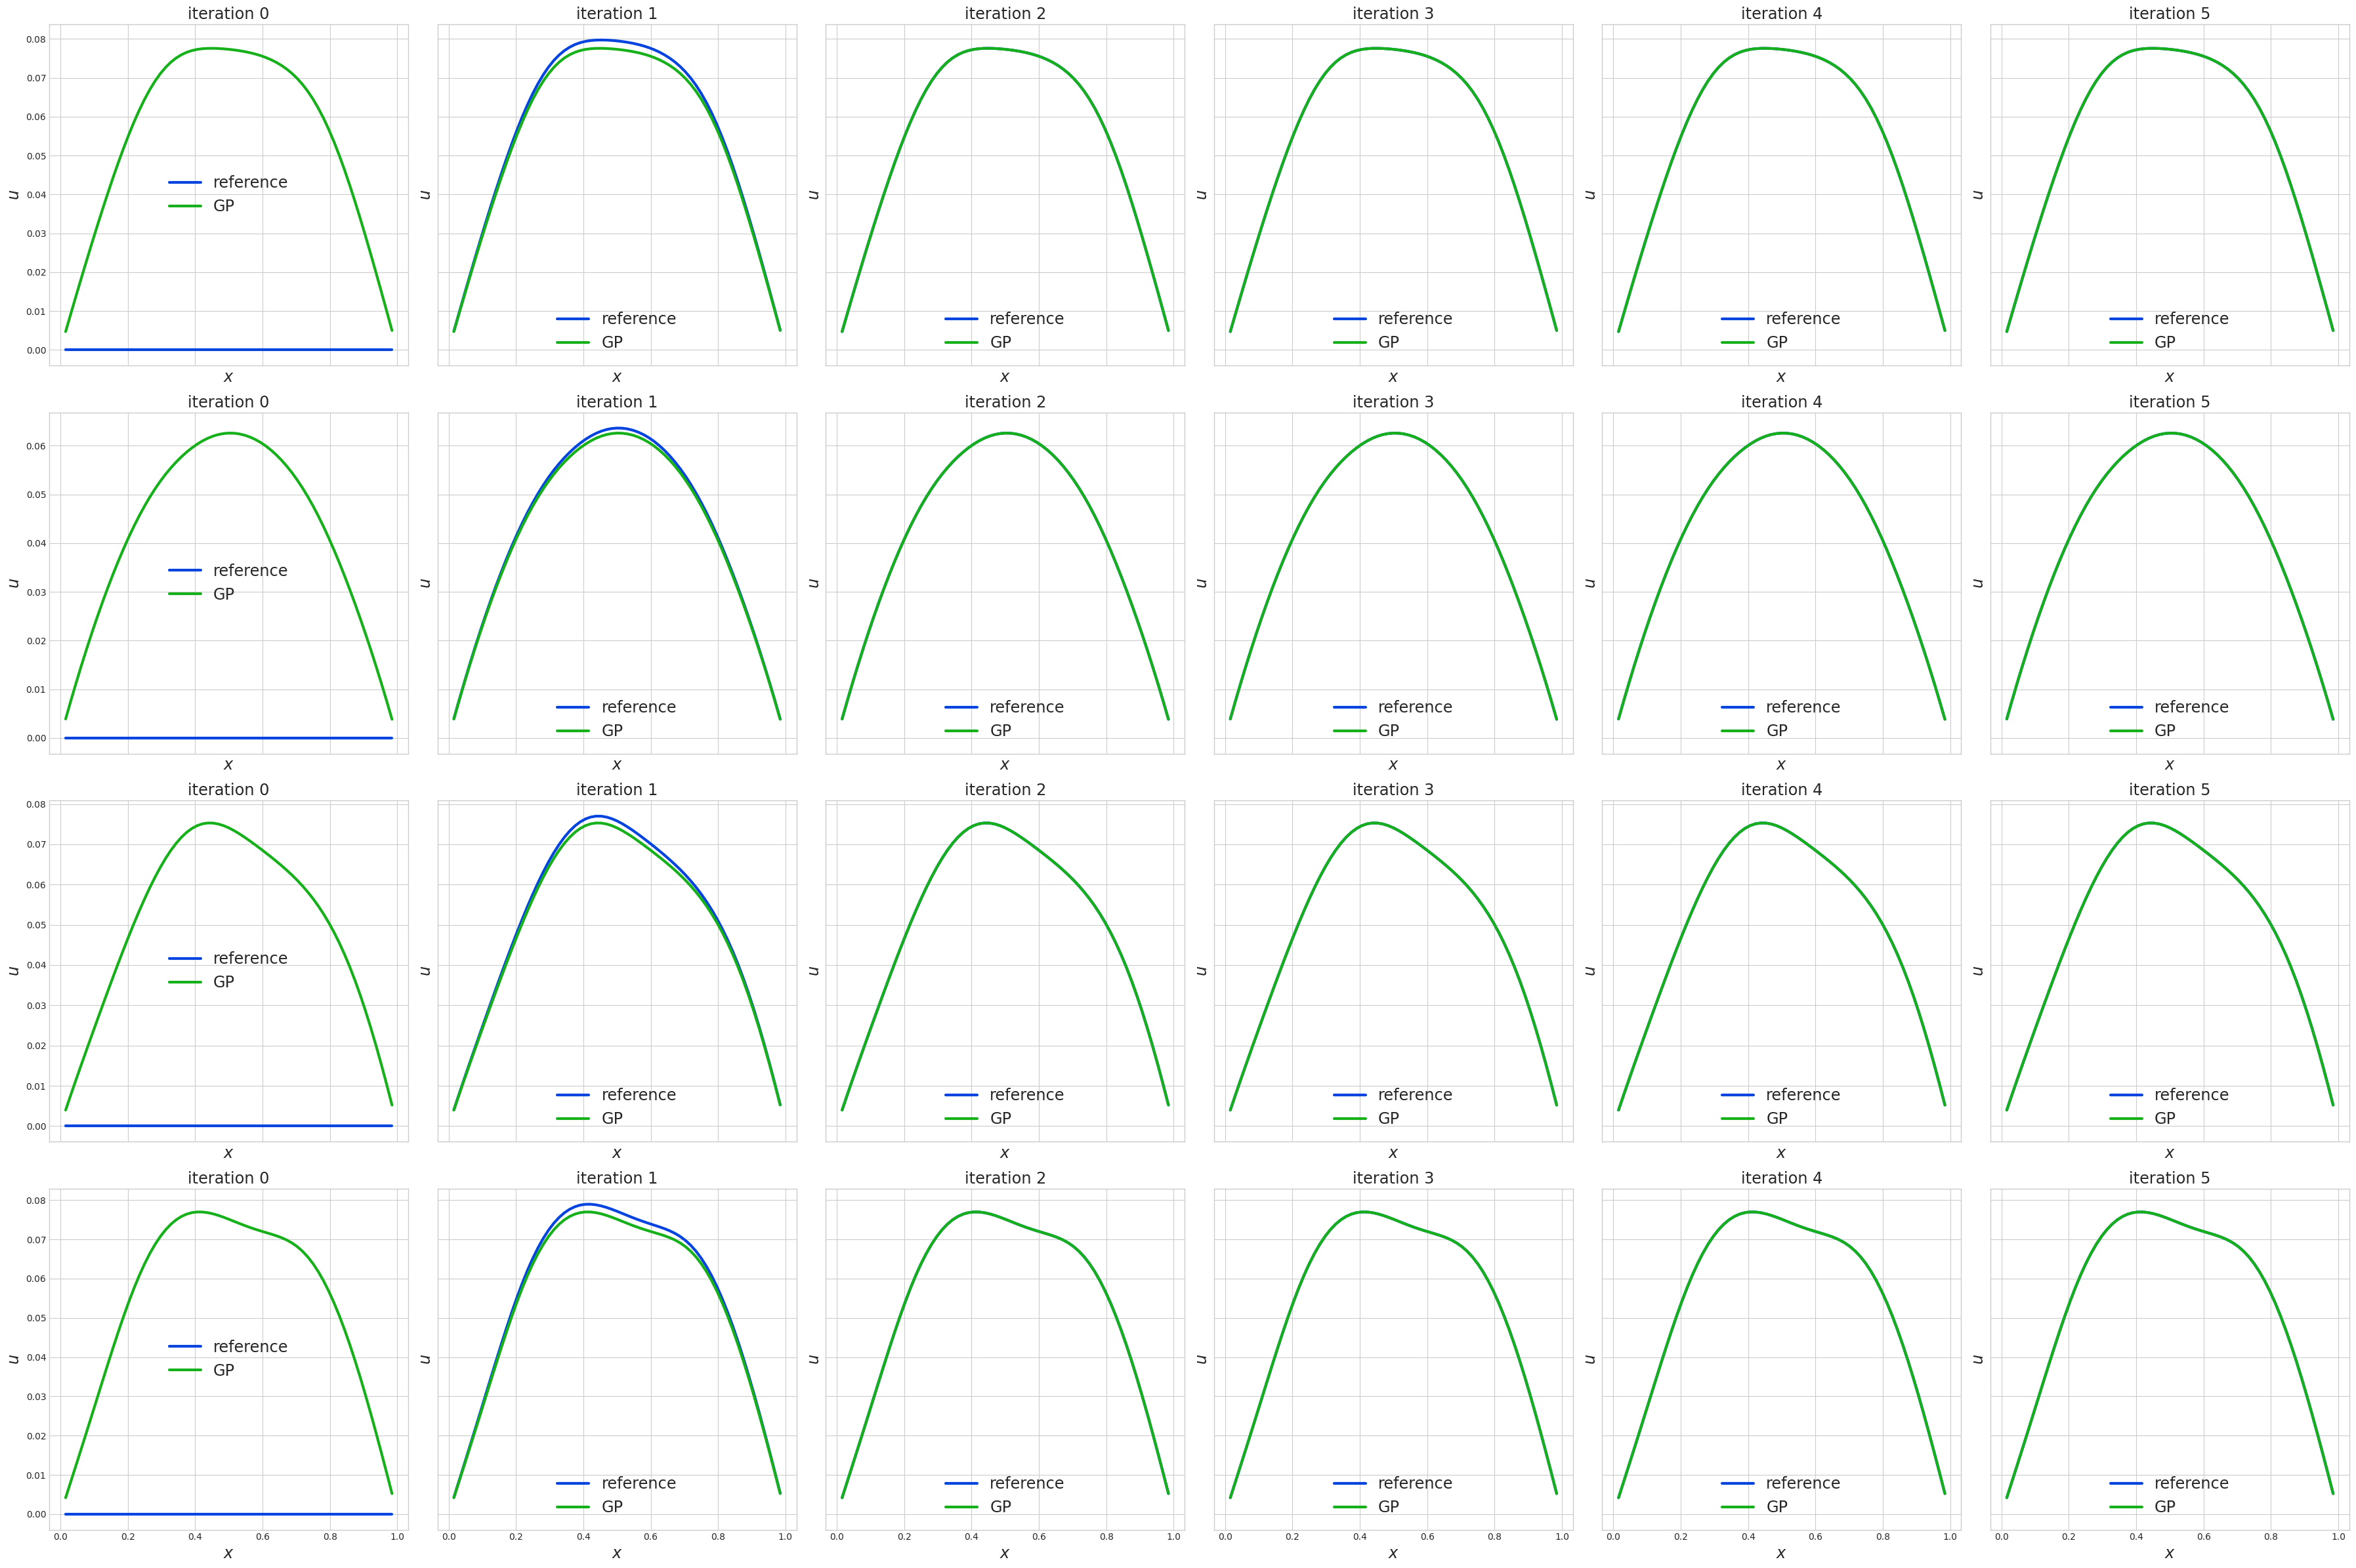

In [19]:
fig,ax = chonknoris.plot_band_strand(
    data = [[[(x.cpu(),data_ig["vs"][i,j],name) for name,data_ig in data_igs.items() if name not in hidden_models] for j in range(vs_v.size(1))] for i in range(4)],
    marker = None, 
    plot_strands = True, 
    plot_median = False, 
    qlows=[], 
    qhighs = [], 
    plt_band_alphas=[],
    LWTHIN=3,
    sharex = True,
    sharey = "row", 
    xlabels = r"$x$",
    ylabels = r"$u$",
    colors=COLORS,
    titles = ["iteration %d"%j for j in range(vs_v.size(1))],
)

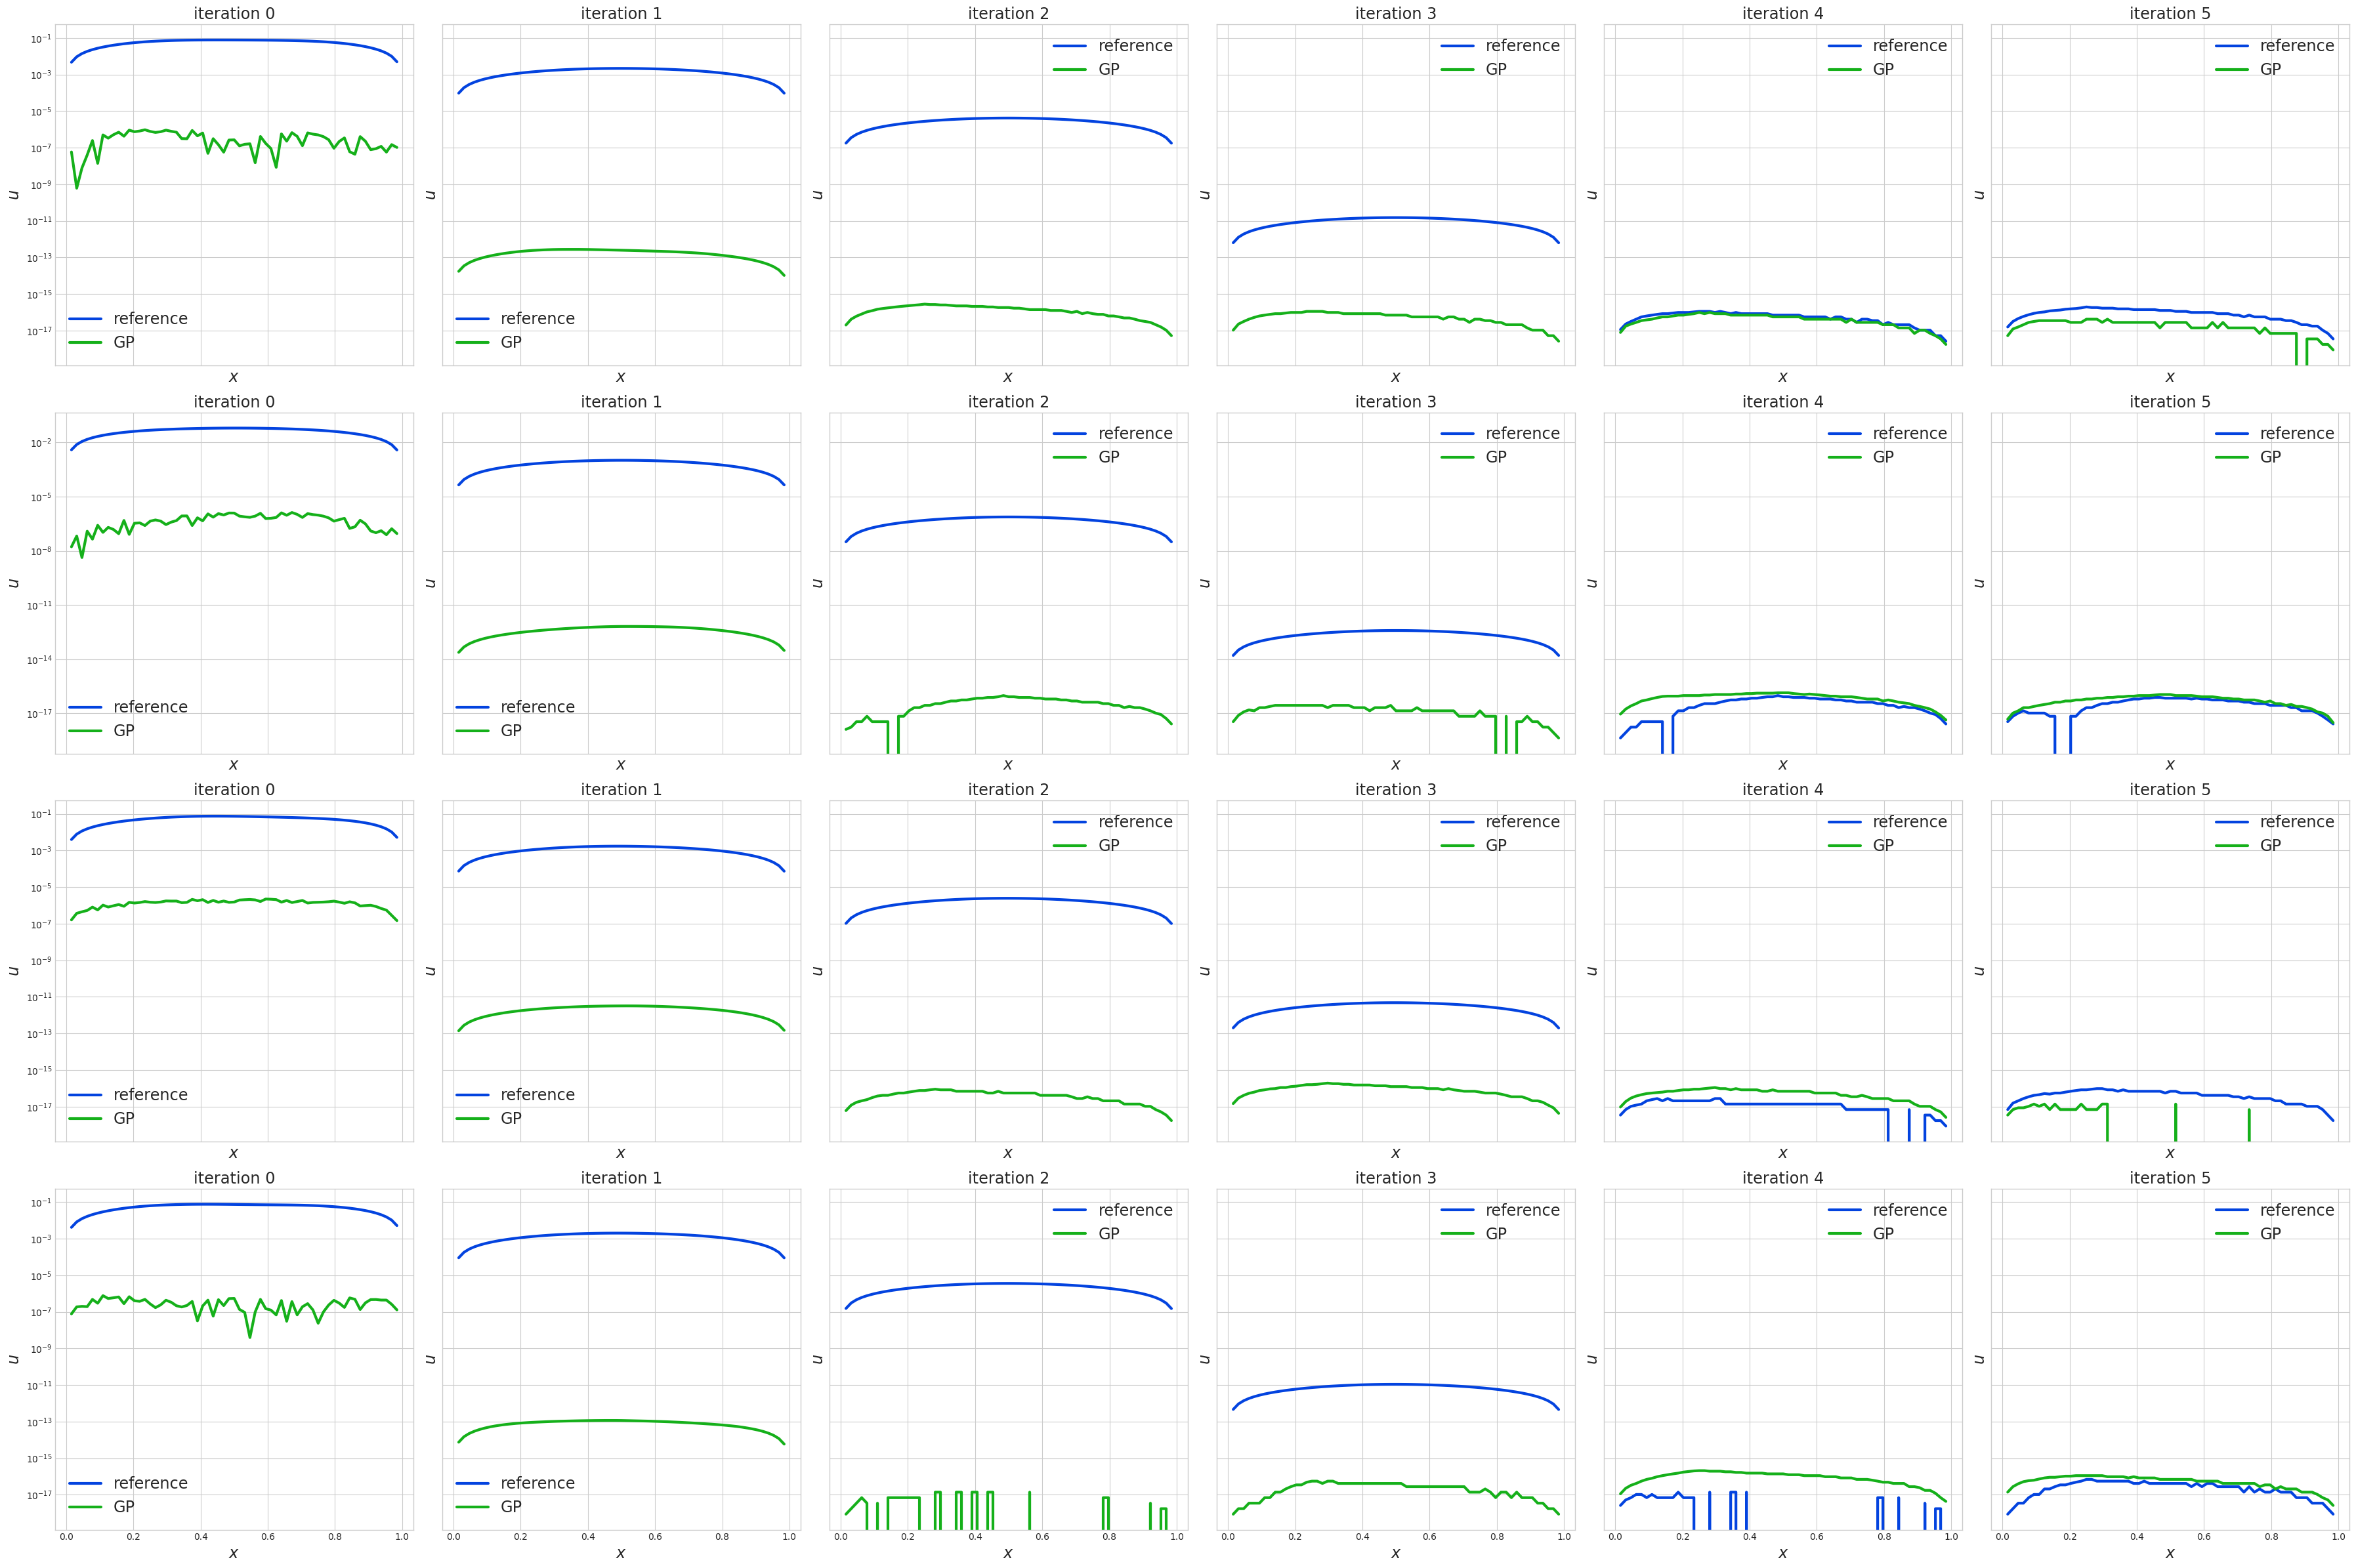

In [20]:
fig,ax = chonknoris.plot_band_strand(
    data = [[[(x.cpu(),torch.abs(data_ig["vs"][i,j]-vs_v[i,-1]),name) for name,data_ig in data_igs.items() if name not in hidden_models] for j in range(vs_v.size(1))] for i in range(4)],
    marker = None, 
    plot_strands = True, 
    plot_median = False, 
    qlows=[], 
    qhighs = [], 
    plt_band_alphas=[],
    LWTHIN=3,
    sharex = True,
    sharey = "row",
    ylogscale=True, 
    xlabels = r"$x$",
    ylabels = r"$u$",
    colors=COLORS,
    titles = ["iteration %d"%j for j in range(vs_v.size(1))],
)

## Operator Learning Cholesky Factors

In [21]:
relaxation = 0#1e-1
lti0,lti1 = torch.tril_indices(N,N,device=DEVICE)
L_t = torch.linalg.solve_triangular(Linvs_t.to(DEVICE),torch.eye(N,device=DEVICE),upper=False)
L_v = torch.linalg.solve_triangular(Linvs_v.to(DEVICE),torch.eye(N,device=DEVICE),upper=False)
Theta_t = torch.einsum("...ik,...jk->...ij",L_t,L_t)
Theta_v = torch.einsum("...ik,...jk->...ij",L_v,L_v)
L_t = torch.linalg.cholesky(Theta_t+relaxation*torch.eye(N,device=DEVICE))
L_v = torch.linalg.cholesky(Theta_v+relaxation*torch.eye(N,device=DEVICE))
Linvs_lam_t = torch.linalg.solve_triangular(L_t,torch.eye(N,device=DEVICE),upper=False)
Linvs_lam_v = torch.linalg.solve_triangular(L_v,torch.eye(N,device=DEVICE),upper=False)
Lf_t = Linvs_lam_t[:,:,lti0,lti1].flatten(end_dim=-2)
Lf_v = Linvs_lam_v[:,:,lti0,lti1].flatten(end_dim=-2)
Lf_t_mean = Lf_t.mean(0) 
Lf_t_std = Lf_t.std(0)
Lf_t_std[Lf_t_std==0] = 1
Lf_t = (Lf_t-Lf_t_mean)/Lf_t_std
Lf_v = (Lf_v-Lf_t_mean)/Lf_t_std
vsf_t = vs_t[:,:-1].to(DEVICE).flatten(end_dim=-2)
vsf_v = vs_v[:,:-1].to(DEVICE).flatten(end_dim=-2)
vsf_t_mean = vsf_t.mean(0)
vsf_t_std = vsf_t.std(0)
vsf_t = (vsf_t-vsf_t_mean)/vsf_t_std
vsf_v = (vsf_v-vsf_t_mean)/vsf_t_std
print("vsf_t.shape = %s"%str(tuple(vsf_t.shape)))
print("Lf_t.shape = %s"%str(tuple(Lf_t.shape)))
print("vsf_v.shape = %s"%str(tuple(vsf_v.shape)))
print("Lf_v.shape = %s"%str(tuple(Lf_v.shape)))

vsf_t.shape = (4480, 63)
Lf_t.shape = (4480, 2016)
vsf_v.shape = (640, 63)
Lf_v.shape = (640, 2016)


     iter of 2.5e+01 | best loss  | loss      
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
            0.00e+00 | 3.75e+01   | 3.75e+01  
            3.00e+00 | 1.60e+01   | 5.32e+00  


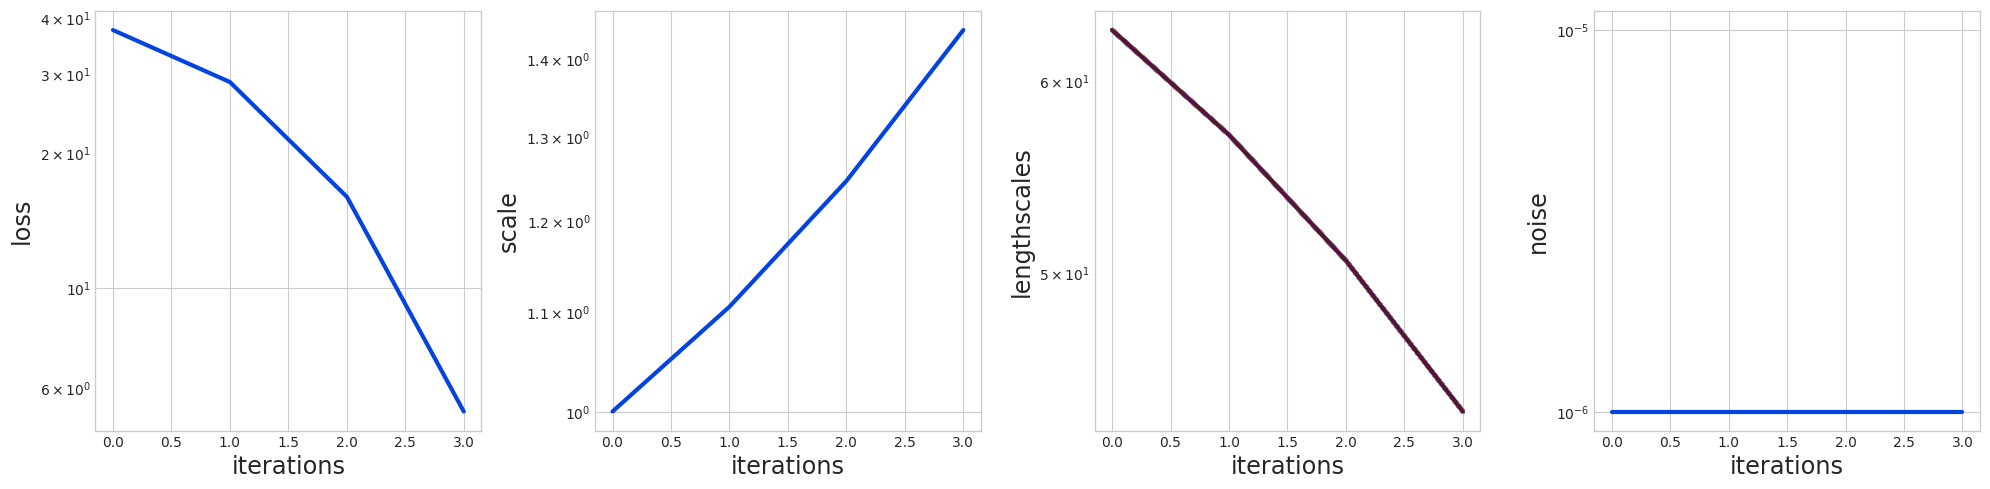

In [22]:
load_params = False 
save_params = False
iterations = 25
d_in = N
d_out = len(lti0)
fgp = fastgps.StandardGP(
    qp.KernelGaussian(
        d_in,
        scale = 1, 
        shape_scale = [1],
        lengthscales=N, 
        shape_lengthscales = [d_in],
        torchify = True,
        compile_call = True,
        device = DEVICE,
    ),
    {"x":vsf_t.to(DEVICE),"y":Lf_t.T.to(DEVICE)},
    noise = 1e-6, 
    shape_noise = [1],
    requires_grad_noise = False, 
)
if load_params: 
    fgp.load_params("./out/fgp_params.pt")
fit_data_fgp = fgp.fit(
    loss_metric = "CV",
    cv_weights = 1/torch.linalg.norm(Lf_t,dim=-1).to(DEVICE),
    iterations = iterations,
    stop_crit_wait_iterations = np.inf,
    store_hists = True,
    verbose = 5,
)
fastgps.plot_fastgps_fit_data(fit_data_fgp,["loss","scale","lengthscales","noise"],dict_log_scale=None);
if save_params:
    fgp.save_params("./out/fgp_params.pt")

### Inference

In [23]:
store_Linvs = False # will slow down runtime
num_newton_iter = 12
line_search = True
lr = 1.
verbose = max(1,num_newton_iter//20)
v0_infer_v = torch.zeros((len(vidx),N),device=DEVICE)
data_Linvs = {}
with chonknoris.TorchNumThreadsContext(1):
    _,data_Linvs["NK"] = pde_solve(u_v,v0_infer_v,num_newton_iter=5,relaxation=0,lr=lr,vref=vs_v[:,-1,:].to(DEVICE),verbose=1,store_Linvs=store_Linvs,line_search=False)
    _,data_Linvs["NK + Initial Guess"] = pde_solve(u_v,v0hat_v_fastgp,num_newton_iter=5,relaxation=0,lr=lr,vref=vs_v[:,-1,:].to(DEVICE),verbose=1,store_Linvs=store_Linvs,line_search=False)
def predict_Linvs(vs):
    Lhatinv = torch.zeros((vs.size(0),N,N),device=DEVICE)
    Lfhat = fgp.post_mean((vs-vsf_t_mean)/vsf_t_std).T.detach()
    Lhatinv[:,lti0,lti1] = Lfhat*Lf_t_std+Lf_t_mean
    return Lhatinv
with chonknoris.TorchNumThreadsContext(1):
    _,data_Linvs["CHONKNORIS"] = pde_solve(u_v,v0_infer_v,num_newton_iter=num_newton_iter,relaxation=0,lr=lr,vref=vs_v[:,-1,:].to(DEVICE),verbose=verbose,predict_Linvs=predict_Linvs,store_Linvs=store_Linvs,line_search=line_search)
    _,data_Linvs["CHONKNORIS + Initial Guess"] = pde_solve(u_v,v0hat_v_fastgp,num_newton_iter=num_newton_iter,relaxation=0,lr=lr,vref=vs_v[:,-1,:].to(DEVICE),verbose=verbose,predict_Linvs=predict_Linvs,store_Linvs=store_Linvs,line_search=line_search)
print()

    iter of 5      | time      | RMSE residual                                       | L2 relative error                                   |
                   |           | 5%           median       mean         95%          | 5%           median       mean         95%          |
    ----------------------------------------------------------------------------------------------------------------------------------------
    0              | 1.41e-03  | 2.18e-01     6.61e-01     8.21e-01     1.75e+00     | 1.00e+00     1.00e+00     1.00e+00     1.00e+00     |
    1              | 1.92e-03  | 1.33e-05     1.09e-02     8.55e-02     2.93e-01     | 1.89e-04     1.93e-02     4.27e-02     1.38e-01     |
    2              | 1.57e-03  | 2.13e-12     1.25e-05     5.71e-03     1.21e-02     | 3.22e-11     2.18e-05     1.74e-03     5.85e-03     |
    3              | 1.51e-03  | 2.18e-15     1.59e-11     9.90e-05     2.18e-05     | 3.52e-16     2.75e-11     2.26e-05     1.05e-05     |
    4        

In [24]:
torch.save(
    {
        "x": x,
        "u_v": u_v,
        "vs_v": vs_v, 
        "data_Linvs": data_Linvs, 
    },
    ROOT+"/out/data_final_plot.elliptic_pde_1d.pt")

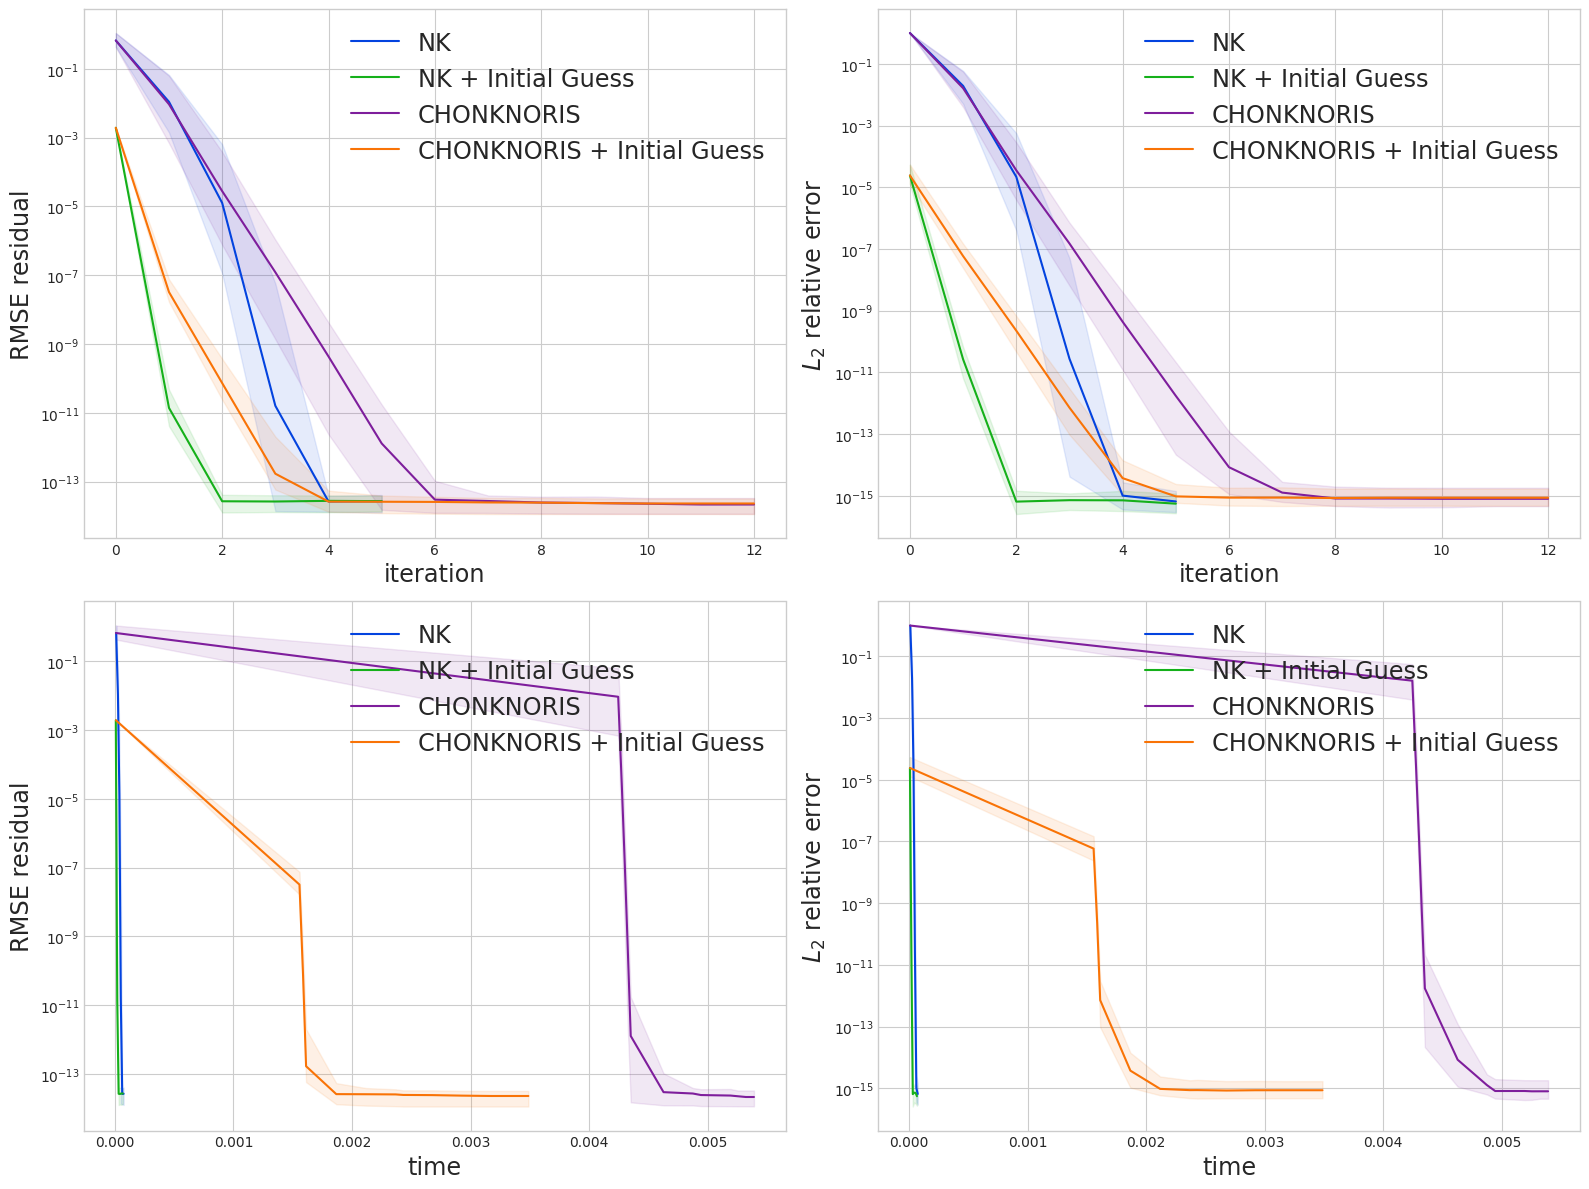

In [25]:
fig,ax = chonknoris.plot_band_strand(
    data = [
        [
            [(None,data_Linv["rmse_resid"],name) for name,data_Linv in data_Linvs.items()],
            [(None,data_Linv["l2rerrors"],name) for name,data_Linv in data_Linvs.items()],

        ],
        [
            [(data_Linv["times"],data_Linv["rmse_resid"],name) for name,data_Linv in data_Linvs.items()],
            [(data_Linv["times"],data_Linv["l2rerrors"],name) for name,data_Linv in data_Linvs.items()],

        ],
    ],
    xlabels = [["iteration"],["time"]],
    ylabels = [["RMSE residual",r"$L_2$ relative error"]],
    xlogscale = False,
    ylogscale=True,
    marker = None,
    colors=COLORS,
    qhighs=[.75],
    qlows=[.25],
    plot_mean=False,
    fsx=6,
    fsy=8)
fig.savefig("out/L_pred_convergence.pdf")

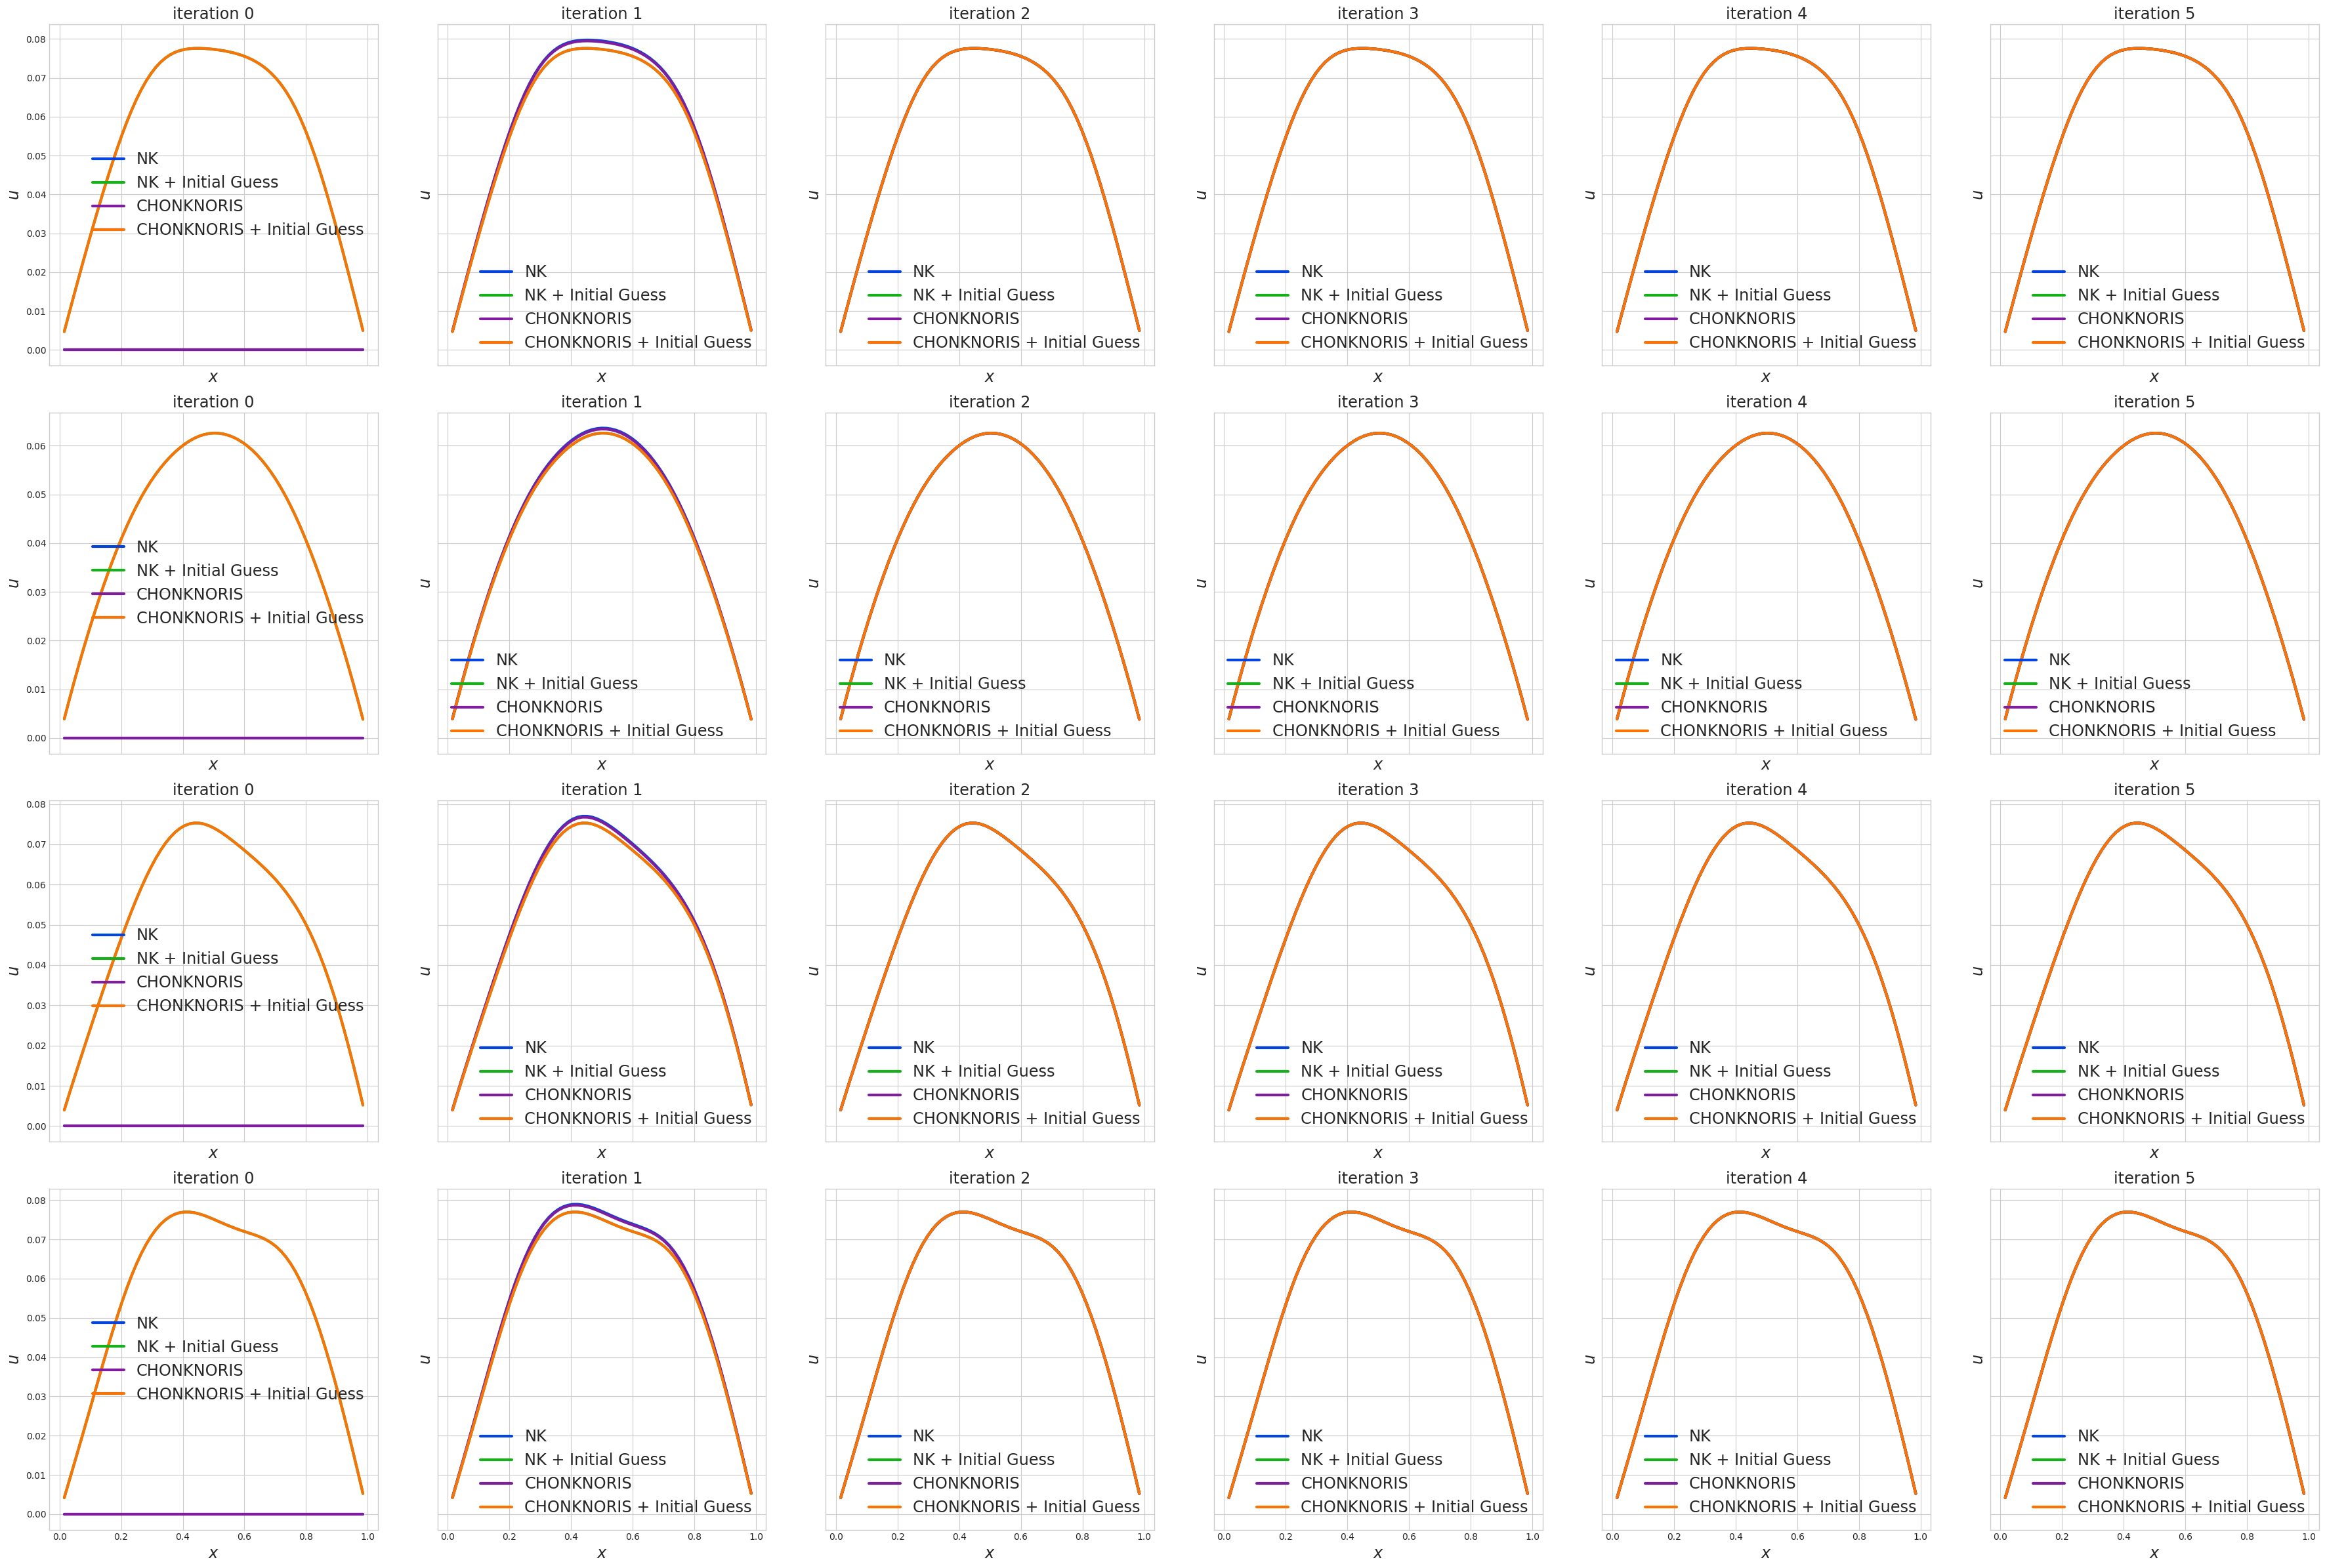

In [26]:
fig,ax = chonknoris.plot_band_strand(
    data = [[[(x.cpu(),data_Linv["vs"][i,j],name) for name,data_Linv in data_Linvs.items()] for j in range(vs_v.size(1))] for i in range(4)],
    marker = None, 
    plot_strands = True, 
    plot_median = False, 
    qlows=[], 
    qhighs = [], 
    plt_band_alphas=[],
    LWTHIN=3,
    sharex = True,
    sharey = "row",
    xlabels = r"$x$",
    ylabels = r"$u$",
    colors=COLORS,
    titles = ["iteration %d"%j for j in range(vs_v.size(1))],
)

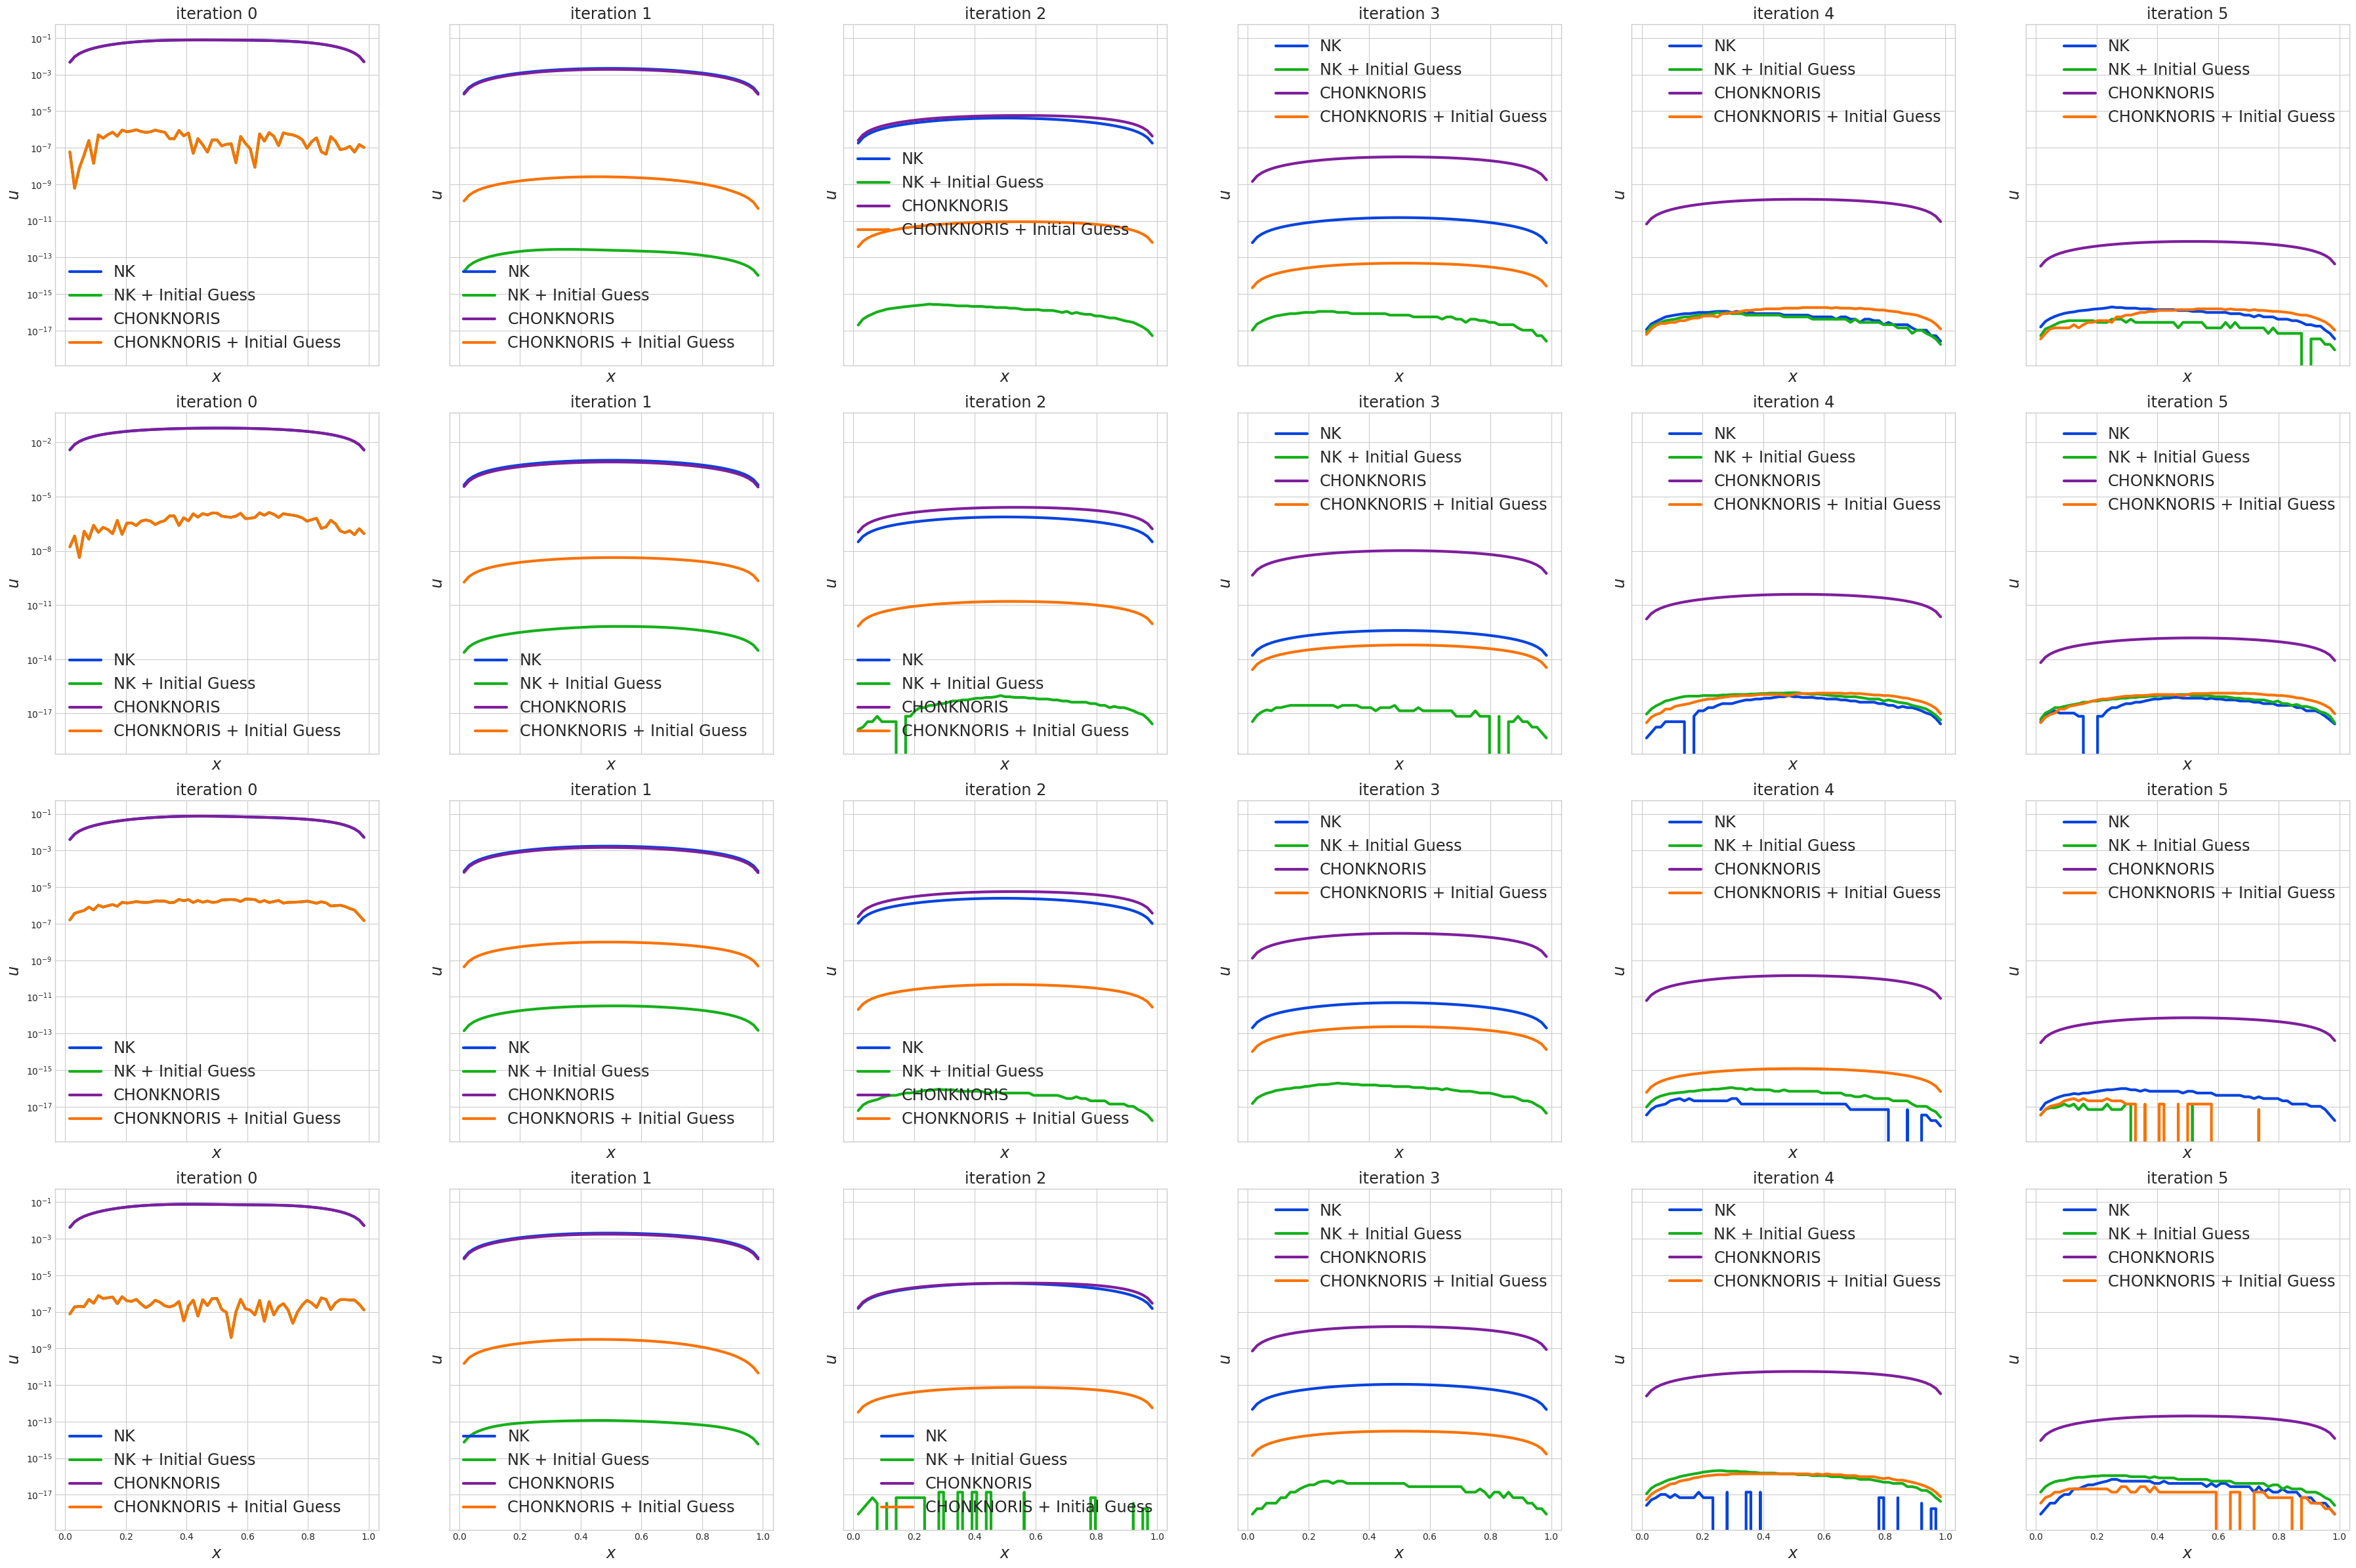

In [27]:
fig,ax = chonknoris.plot_band_strand(
    data = [[[(x.cpu(),torch.abs(data_Linv["vs"][i,j]-vs_v[i,-1]),name) for name,data_Linv in data_Linvs.items()] for j in range(vs_v.size(1))] for i in range(4)],
    marker = None, 
    plot_strands = True, 
    plot_median = False, 
    qlows=[], 
    qhighs = [], 
    plt_band_alphas=[],
    LWTHIN=3,
    sharex = True,
    sharey = "row",
    ylogscale=True, 
    xlabels = r"$x$",
    ylabels = r"$u$",
    colors=COLORS,
    titles = ["iteration %d"%j for j in range(vs_v.size(1))],
)

## Timing Comparisonm

In [28]:
N_times_comp = 8

In [29]:
with torch.no_grad(), torch.inference_mode(), gpytorch.settings.fast_pred_var(), chonknoris.TorchNumThreadsContext(1):
    times_ig = torch.empty(N_times_comp)
    for i in range(N_times_comp):
        t0 = torch.cuda.Event(enable_timing=True)
        tend = torch.cuda.Event(enable_timing=True)
        t0.record()
        _ig_tf_x = (u_v[[i]].to(DEVICE)-ig_x_mean)/ig_x_std
        # _ig_tf_x = ((((u_v.to(DEVICE)-ig_x_mean)/ig_x_std)@pcamat_ig_x)-ig_x_pca_mean)/ig_x_pca_std
        _ig_tf_y = fgp_ig.post_mean(_ig_tf_x).T
        _v0hat_v_fastgp = ig_y_mean+ig_y_std*_ig_tf_y
        # _v0hat_v_fastgp = ig_y_mean+ig_y_std*((ig_y_pca_mean+ig_y_pca_std*_ig_tf_y)@(pcamat_ig_y.conj().T))
        tend.record()
        torch.cuda.synchronize()
        times_ig[i] = t0.elapsed_time(tend)/1000
    print("times_ig")
    print(times_ig) 
    print("times_ig.median() = %.1e"%times_ig.median())

times_ig
tensor([0.1636, 0.0015, 0.0013, 0.0012, 0.0012, 0.0012, 0.0012, 0.0012])
times_ig.median() = 1.2e-03


In [ ]:
with torch.no_grad(), torch.inference_mode(), gpytorch.settings.fast_pred_var(), chonknoris.TorchNumThreadsContext(1):
    times_chonknoris_model = torch.empty(N_times_comp)
    for i in range(N_times_comp):
        t0 = torch.cuda.Event(enable_timing=True)
        tend = torch.cuda.Event(enable_timing=True)
        t0.record()
        fgp.post_mean(torch.rand(1,63,device=DEVICE))
        tend.record()
        torch.cuda.synchronize()
        times_chonknoris_model[i] = t0.elapsed_time(tend)/1000
    print("times_chonknoris_model")
    print(times_chonknoris_model) 
    print("times_chonknoris_model.median() = %.1e"%times_chonknoris_model.median())

times_chonknoris_model
tensor([0.1046, 0.0013, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011, 0.0011])
times_chonknoris_model.median() = 1.1e-03


In [31]:
with torch.no_grad(), torch.inference_mode(), gpytorch.settings.fast_pred_var(), chonknoris.TorchNumThreadsContext(1):
    times_chonknoris = torch.empty(N_times_comp)
    for i in range(N_times_comp):
        t0 = torch.cuda.Event(enable_timing=True)
        tend = torch.cuda.Event(enable_timing=True)
        t0.record()
        _ = pde_solve(u_v[[i]],v0hat_v_fastgp[[i]],num_newton_iter=5,relaxation=0,lr=lr,vref=vs_v[[i],-1,:].to(DEVICE),verbose=10,predict_Linvs=predict_Linvs,store_Linvs=store_Linvs,line_search=line_search)
        tend.record()
        torch.cuda.synchronize()
        times_chonknoris[i] = t0.elapsed_time(tend)/1000
    print("times_chonknoris")
    print(times_chonknoris) 
    print("times_chonknoris.median() = %.1e"%times_chonknoris.median())

    iter of 5      | time      | RMSE residual                                       | L2 relative error                                   |
                   |           | 5%           median       mean         95%          | 5%           median       mean         95%          |
    ----------------------------------------------------------------------------------------------------------------------------------------
    0              | 9.45e-04  | 1.94e-03     1.94e-03     1.94e-03     1.94e-03     | 7.44e-06     7.44e-06     7.44e-06     7.44e-06     |
    5              | 2.05e-03  | 3.02e-14     3.02e-14     3.02e-14     3.02e-14     | 3.68e-16     3.68e-16     3.68e-16     3.68e-16     |
    iter of 5      | time      | RMSE residual                                       | L2 relative error                                   |
                   |           | 5%           median       mean         95%          | 5%           median       mean         95%          |
    ---------